In [1]:
import mace
from mace.calculators import MACECalculator

import ase
from ase.io import read, write
import numpy as np
import os
import matplotlib.pyplot as plt

from ase.build import graphene, make_supercell

from ase.optimize import BFGS
from ase.filters import FrechetCellFilter

from ase.visualize import view

from ase.phonons import Phonons

from tqdm import tqdm

/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/e3nn/o3/_wigner.py:10: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  _Jd, _W3j_flat, _W3j_indices = torch.load(os.path.join(os.path.dirname(__file__), 'constants.pt'))
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_script.py:1488: DeprecationWarning: `torch.jit.script` is deprecated. Please switch to `torch.compile` or `torch.export`.
  warnings.warn(


In [2]:
DEG2RAG = np.pi / 180

In [3]:
import subprocess
ROOT = subprocess.check_output(["git", "rev-parse", "--show-toplevel"], text=True).strip()

model_path = f"{ROOT}/KAGGLE_DOWNLOAD/from_C2_v1/MACE.model"
model = MACECalculator(model_path=model_path, device="cuda")

/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/mace/calculators/mace.py:197: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  torch.load(f=model_path, map_location=device)


Using head Default out of ['Default']
No dtype selected, switching to float32 to match model dtype.


/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(
/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/torch/jit/_serialization.py:176: DeprecationWarning: `torch.jit.load` is deprecated. Please switch to `torch.export`.
  warnings.warn(


In [4]:
graphene_pristine = graphene()
graphene_pristine.calc = model
graphene_pristine.cell[2,2] = 100

filter = FrechetCellFilter(graphene_pristine, mask = [1,1,0,0,0,0])
opt = BFGS(filter)
opt.run(fmax = 1e-5)

      Step     Time          Energy          fmax
BFGS:    0 13:44:05      -15.917213        0.007294
BFGS:    1 13:44:06      -15.917213        0.001838
BFGS:    2 13:44:06      -15.917213        0.000026
BFGS:    3 13:44:06      -15.917215        0.000005


np.True_

In [5]:
# nx = 20
# ny = 15

# supercell_matrix = np.array([
#     [nx, nx, 0], 
#     [-ny, ny, 0],
#     [0, 0, 1]
# ])

# supercell = make_supercell(graphene_pristine, supercell_matrix)
# supercell.wrap()

In [6]:
# write(f"supercell_{nx}_{ny}.lammps-data", supercell)

In [7]:
# supercell = read(f"supercell_{nx}_{ny}.lammps-data")
# supercell.calc = model

In [8]:
# angle = 23
# rot = 0
# amplitude = 0.24

# C = np.cos(angle * DEG2RAG)
# S = np.sin(angle * DEG2RAG)

# Cr = np.cos(rot * DEG2RAG)
# Sr = np.sin(rot * DEG2RAG)

# ROT = np.array([
#     [Cr, -Sr, 0],
#     [Sr, Cr, 0],
#     [0, 0, 1]
# ])

# strained = supercell.copy()
# strained.calc = model
# strained.set_cell(supercell.cell @ ROT.T, scale_atoms=True)

# strain_versor = np.array([
#     [C, 0, 0],
#     [0, S, 0],
#     [0, 0, 0]
# ])
# strain = amplitude * strain_versor
# deformation = np.eye(3) + strain
# strained.set_cell(supercell.cell @ deformation, scale_atoms=True)

In [9]:
# scale = 5e-2

# shape = strained.positions.shape
# perturbation = np.random.normal(scale=scale, size=shape)
# perturbation[:, 2] = 0

# strained.set_positions(strained.positions + perturbation)

In [10]:
# natoms = len(strained)
# strained.symbols = f"C{natoms}"

In [11]:

# relaxed = strained.copy()
# relaxed.calc = model

# import os
# os.makedirs("RELAXATIONS", exist_ok=True)

# opt = BFGS(relaxed, logfile = "opt.log", trajectory=f"RELAXATIONS/nx{nx}_ny{ny}_angle{angle}_rot{rot:.2f}_amp{amplitude:.2f}.traj")
# opt.run(fmax = 1e-3, steps=100)

In [12]:
deformed_primitive = graphene_pristine.copy()
deformed_primitive.calc = model

opt = BFGS(deformed_primitive)
opt.run(1e-5)

      Step     Time          Energy          fmax
BFGS:    0 13:44:06      -15.917215        0.000004


np.True_

In [13]:
view(deformed_primitive, viewer = "ngl")

In [14]:
angle = 45
rot = 0
amplitude = 0.23

C = np.cos(angle * DEG2RAG)
S = np.sin(angle * DEG2RAG)

Cr = np.cos(rot * DEG2RAG)
Sr = np.sin(rot * DEG2RAG)

ROT = np.array([
    [Cr, -Sr, 0],
    [Sr, Cr, 0],
    [0, 0, 1]
])

strain_versor = np.array([
    [C, 0, 0],
    [0, S, 0],
    [0, 0, 0]
])
strain = amplitude * strain_versor
deformation = np.eye(3) + strain
deformed_primitive.set_cell(deformed_primitive.cell @ deformation, scale_atoms=True)

In [15]:
view(deformed_primitive, viewer="ngl")

In [16]:
ph = Phonons(
    deformed_primitive,
    model,
    supercell = (9, 9, 1),
    delta = 0.01,
    name="cache"
)

ph.run()
ph.read(acoustic=True)
ph.clean()

13

In [17]:
bandpath = deformed_primitive.cell.bandpath()
bandpath = bandpath.interpolate(npoints = 500)
bs, modes = ph.get_band_structure(bandpath, verbose=False, modes = True)

In [18]:
ph.write_modes(np.array([1/3, 1/3, 0]), branches=0, kT=0.001, repeat = (9, 9, 1))

WARNING, 1 imaginary frequencies at q = ( 0.33,  0.33,  0.00) ; (omega_q = 1.808e-01*i)


In [19]:
from ase.io import Trajectory
traj = Trajectory("cache.mode.0.traj")
view(traj, viewer = "ngl")

(-0.0216876735965111, 0.12903867246838466)

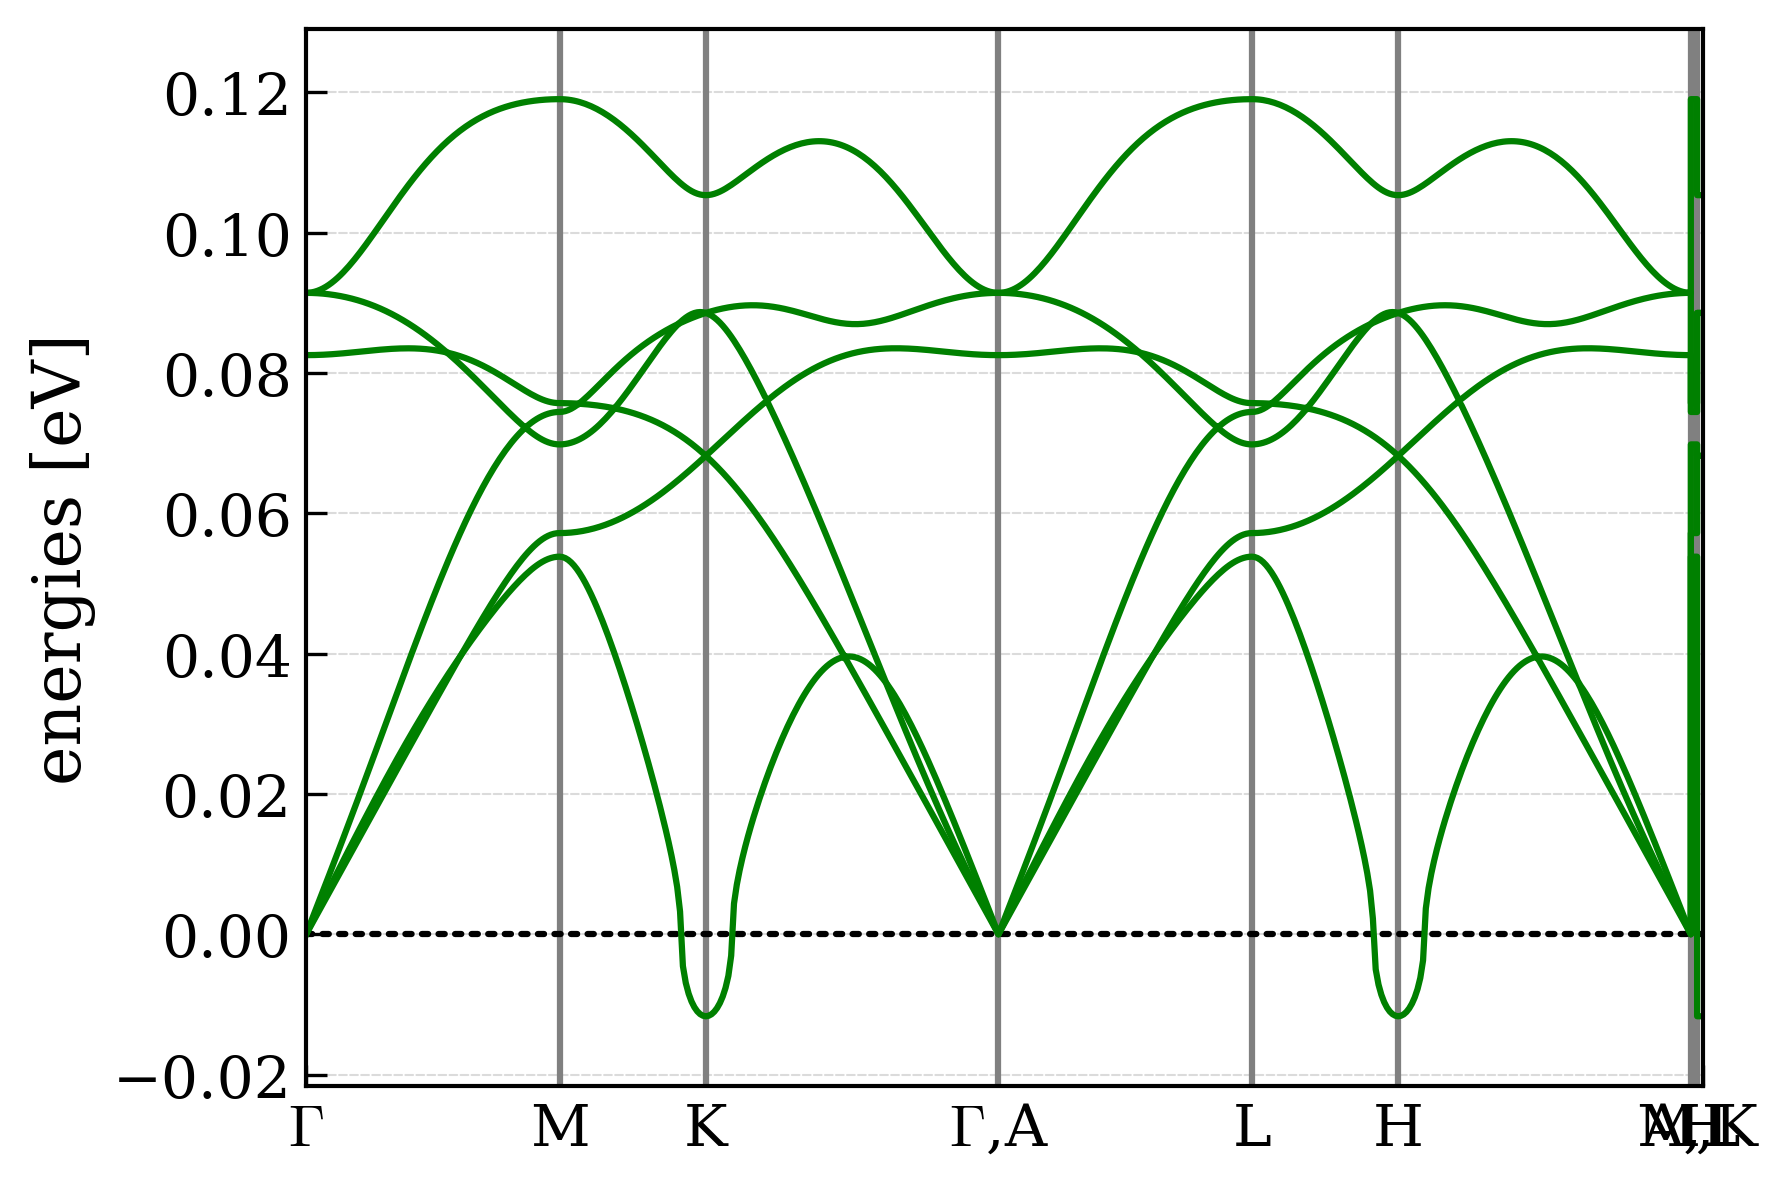

In [20]:
bs.plot()
min = np.min(bs.energies)-0.01
max = np.max(bs.energies)+0.01
plt.ylim(min, max)

In [21]:
bandpath.special_points

{'G': array([0., 0., 0.]),
 'A': array([0. , 0. , 0.5]),
 'H': array([0.33333333, 0.33333333, 0.5       ]),
 'K': array([0.33333333, 0.33333333, 0.        ]),
 'L': array([0.5, 0. , 0.5]),
 'M': array([0.5, 0. , 0. ])}

In [22]:
print(bandpath.kpts.shape)
print(bs.energies.shape)
print(modes.shape)

(500, 3)
(1, 500, 6)
(500, 6, 2, 3)


In [23]:
energies = bs.energies[0] # Shape: (N_kpoints, N_modes)
min_idx = np.argmin(energies)
kidx = min_idx // 6
mode_idx = min_idx % 6
mode = modes[kidx, mode_idx]
kpoint = bandpath.kpts[kidx]
energy = energies[kidx, mode_idx]

In [24]:
mode

array([[-7.13734479e-02+1.25388561e-01j,  1.25371495e-01+7.13740604e-02j,
        -4.22427043e-06-4.13808431e-06j],
       [-7.28924053e-02-1.24504710e-01j,  1.24501232e-01-7.28903525e-02j,
         5.01108475e-06+0.00000000e+00j]])

In [25]:
print(kpoint)
print(mode)
print(energy)

[0.33333333 0.33333333 0.        ]
[[-7.13734479e-02+1.25388561e-01j  1.25371495e-01+7.13740604e-02j
  -4.22427043e-06-4.13808431e-06j]
 [-7.28924053e-02-1.24504710e-01j  1.24501232e-01-7.28903525e-02j
   5.01108475e-06+0.00000000e+00j]]
-0.011687673596511098


In [26]:
mode / np.linalg.norm(mode)

array([[-2.47358171e-01+4.34557751e-01j,  4.34498607e-01+2.47360294e-01j,
        -1.46400074e-05-1.43413131e-05j],
       [-2.52622405e-01-4.31494599e-01j,  4.31482547e-01-2.52615290e-01j,
         1.73668611e-05+0.00000000e+00j]])

In [27]:
modes[kidx]

array([[[-7.13734479e-02+1.25388561e-01j,
          1.25371495e-01+7.13740604e-02j,
         -4.22427043e-06-4.13808431e-06j],
        [-7.28924053e-02-1.24504710e-01j,
          1.24501232e-01-7.28903525e-02j,
          5.01108475e-06+0.00000000e+00j]],

       [[ 3.49039970e-06+7.24067489e-06j,
          1.68164790e-07+2.78814222e-06j,
          2.56538869e-01+9.65697302e-02j],
        [ 7.32464521e-07-7.34920397e-06j,
         -1.16154572e-06-4.65036843e-06j,
         -9.01061042e-02+0.00000000e+00j]],

       [[ 1.28813091e-06+2.43604020e-06j,
         -7.45627008e-06-2.47418673e-06j,
          8.43291748e-02+3.17442957e-02j],
        [-9.64674101e-06-7.59426805e-07j,
         -1.04380432e-06+8.99846876e-06j,
          2.74112940e-01+0.00000000e+00j]],

       [[ 1.70130294e-01+5.18153623e-02j,
         -5.18077823e-02+1.70173914e-01j,
         -7.59000413e-06-7.84110996e-08j],
        [ 6.65713500e-02-7.45511466e-02j,
         -7.45906471e-02-6.65678262e-02j,
          5.24839729e

In [28]:
import energy_vs_amplitude
from energy_vs_amplitude import *


In [29]:

kpoint2 = -kpoint
print(kpoint2)

bs2, modes2 = ph.band_structure([kpoint2], modes=True)
print(bs2)

[-0.33333333 -0.33333333 -0.        ]
WARNING, 1 imaginary frequencies at q = (-0.33, -0.33, -0.00) ; (omega_q = 1.808e-01*i)
[[-0.01168767  0.06819671  0.06819672  0.08856541  0.08856824  0.10535348]]


(-0.5, 0.5)

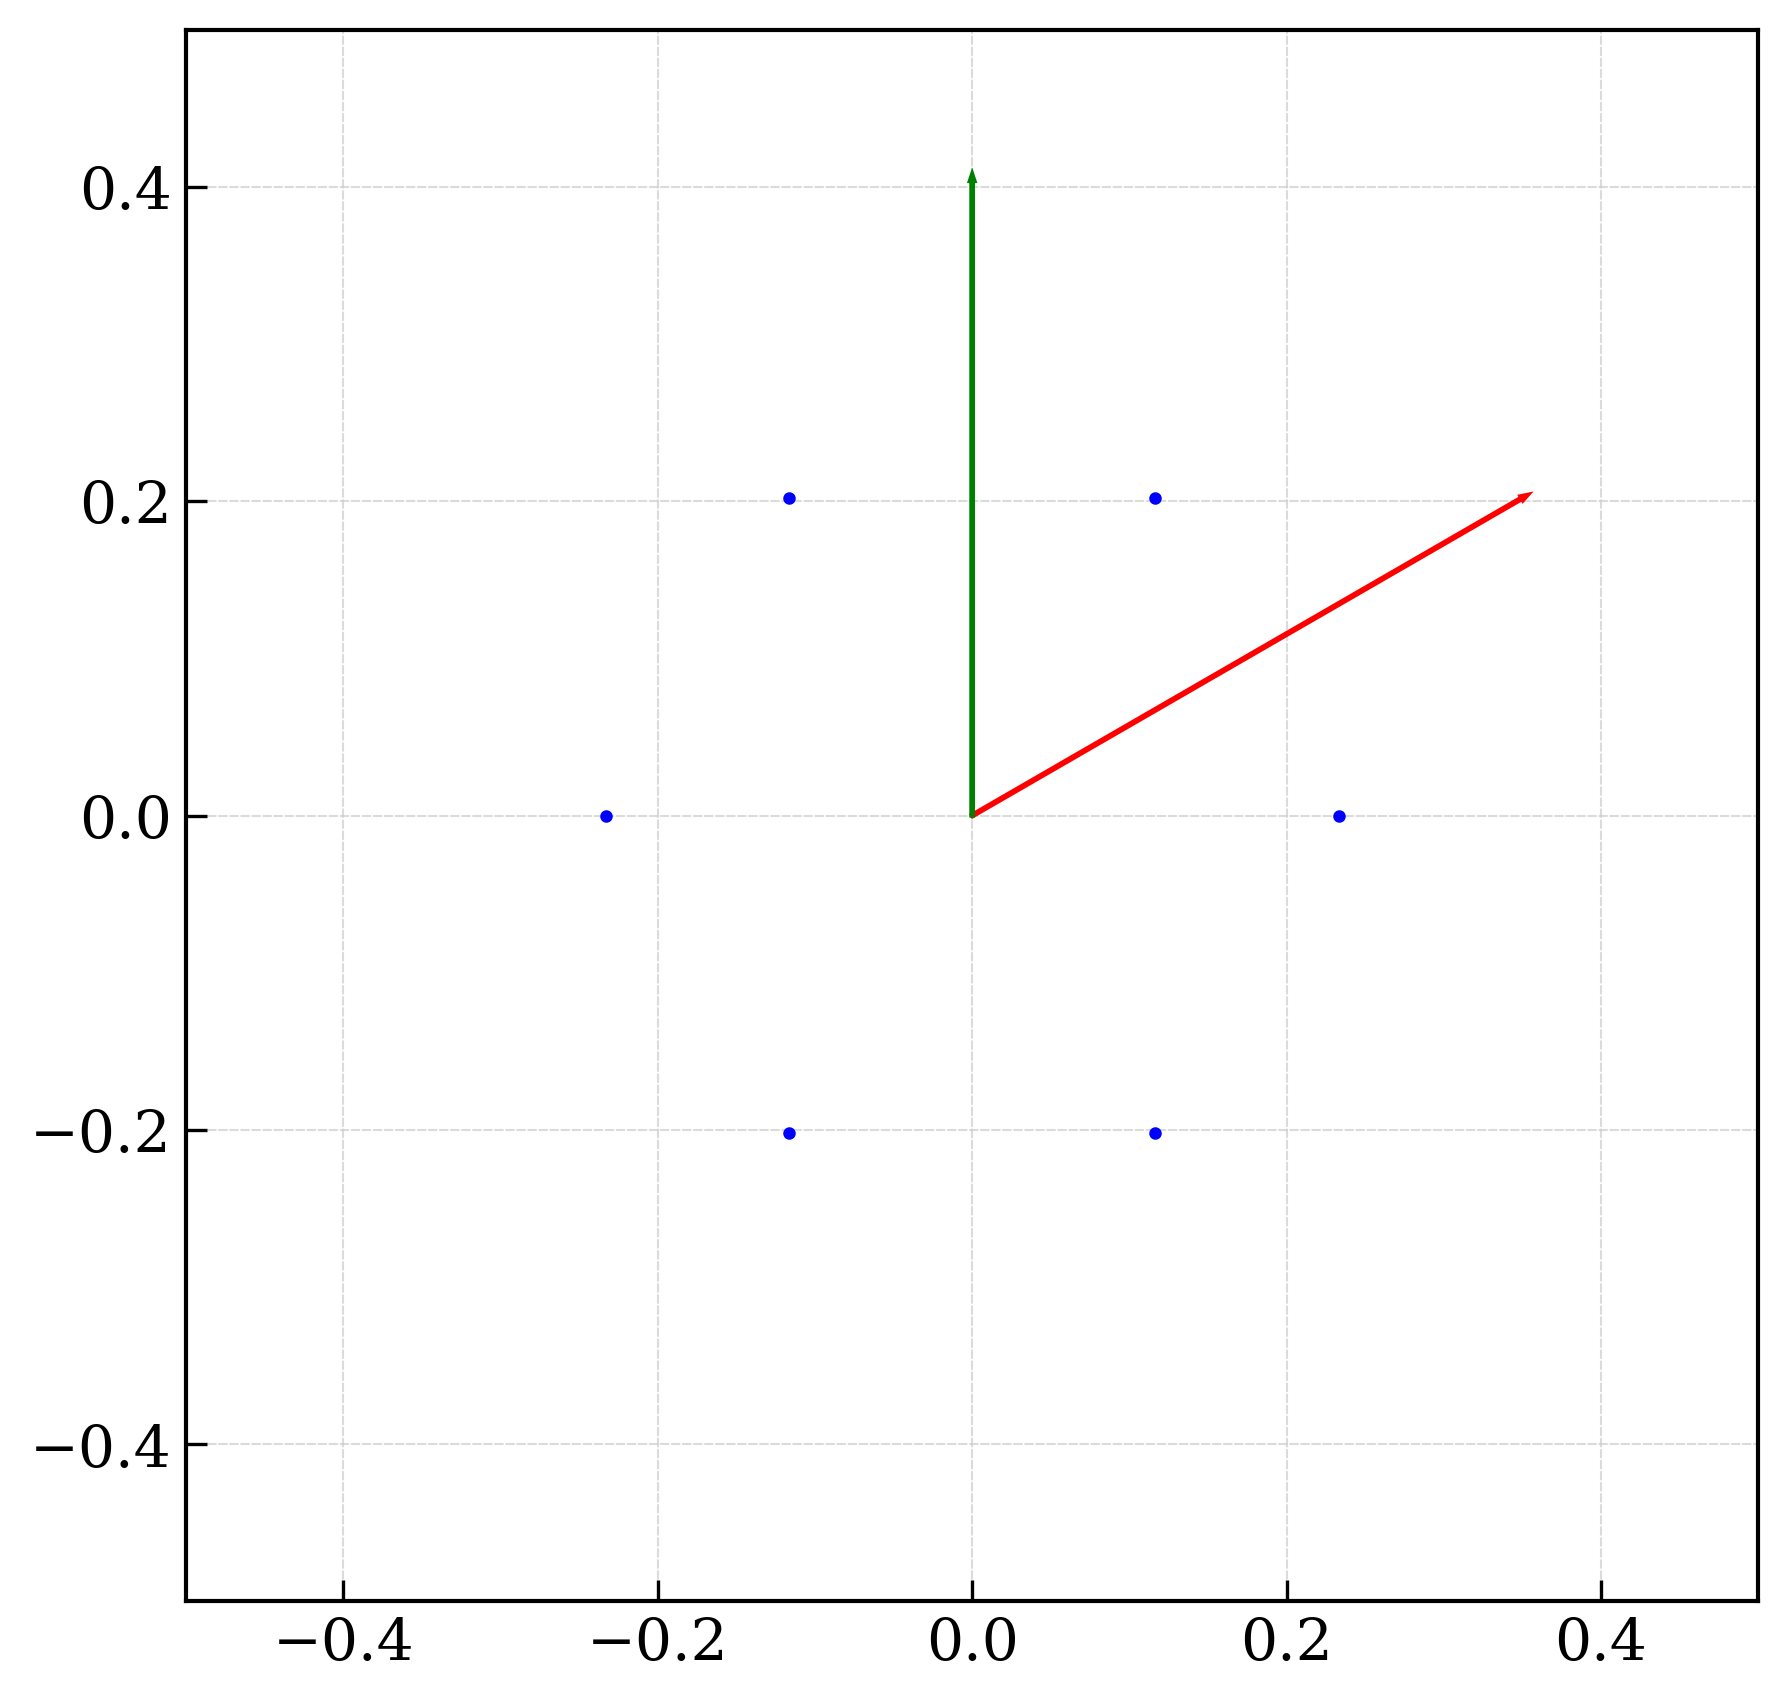

In [30]:
reciprocal_cell = ph.atoms.cell.reciprocal()

ks = np.array([
    [1/3, 1/3, 0],
    [-1/3, -1/3, 0], 
    [-2/3, 1/3, 0],
    [2/3, -1/3, 0],
    [1/3, -2/3, 0],
    [-1/3, 2/3, 0]
])



ks_cartesian = ks @ reciprocal_cell


fig, ax = plt.subplots(figsize=(6,6))

ax.arrow(0, 0, reciprocal_cell[0, 0], reciprocal_cell[0, 1], color="r", label="b1")
ax.arrow(0, 0, reciprocal_cell[1, 0], reciprocal_cell[1, 1], color="g", label="b2")

plt.scatter(ks_cartesian[:,0], ks_cartesian[:,1], color="b", label="k-points")

ax.set_aspect("equal")
ax.set_xlim(-0.5, 0.5)
ax.set_ylim(-0.5, 0.5)

In [31]:
(ks_cartesian[5] - ks_cartesian[1]) - reciprocal_cell[1]

array([-1.47888801e-18,  0.00000000e+00,  0.00000000e+00])

In [32]:
etest, mtest = ph.band_structure(ks, modes=True)

print(etest)
print(mtest[:,0])

WARNING, 1 imaginary frequencies at q = ( 0.33,  0.33,  0.00) ; (omega_q = 1.808e-01*i)
WARNING, 1 imaginary frequencies at q = (-0.33, -0.33,  0.00) ; (omega_q = 1.808e-01*i)
WARNING, 1 imaginary frequencies at q = (-0.67,  0.33,  0.00) ; (omega_q = 1.808e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.67, -0.33,  0.00) ; (omega_q = 1.808e-01*i)
WARNING, 1 imaginary frequencies at q = ( 0.33, -0.67,  0.00) ; (omega_q = 1.808e-01*i)
WARNING, 1 imaginary frequencies at q = (-0.33,  0.67,  0.00) ; (omega_q = 1.808e-01*i)
[[-0.01168767  0.06819671  0.06819672  0.08856541  0.08856824  0.10535348]
 [-0.01168767  0.06819671  0.06819672  0.08856541  0.08856824  0.10535348]
 [-0.01168767  0.06819671  0.06819672  0.08856541  0.08856824  0.10535348]
 [-0.01168767  0.06819671  0.06819672  0.08856541  0.08856824  0.10535348]
 [-0.01168767  0.06819671  0.06819672  0.08856541  0.08856824  0.10535348]
 [-0.01168767  0.06819671  0.06819672  0.08856541  0.08856824  0.10535348]]
[[[-7.13734479e-02+1.

In [33]:
reciprocal_cell

Cell([[0.3496647522668245, 0.20187904434984807, 0.0], [1.4788880132159242e-18, 0.4037580886996962, 0.0], [0.0, 0.0, 0.01]])

In [34]:
k1 = kpoint
k2 = kpoint2
mode1 = mode
mode2 = modes2[0][0]
strain_amplitude = 0.23

mode_amplitudes = np.linspace(-0.05, 0.05, 50)
phase = 0
amp = 1
phase = np.deg2rad(phase)

 
coefficients = np.array(
    [1, amp * np.exp(1j * phase)]
) 

coefficients /= np.linalg.norm(coefficients)

In [35]:
results = {}
phi1 = 0
angle = np.pi/4

for phi2 in tqdm(np.linspace(0, 2*np.pi, 180)):
    coefficients = np.array([np.cos(angle) * np.exp(1j * phi1), np.sin(angle) * np.exp(1j * phi2)])

    configs, energies, _ = energy_mode(
        graphene_pristine, 
        strain_versor, 
        strain_amplitude, 
        np.array([3, 3, 1]),
        model,
        np.array([k1, k2]),
        np.array([mode1, mode2]),
        coefficients,
        mode_amplitudes
    )
    
    results[(angle, phi1, phi2)] = (configs, energies)


100%|██████████| 180/180 [03:56<00:00,  1.31s/it]


In [36]:
def curvature(x, y):
    from numpy import polyfit
    coeffs = polyfit(x, y, 4)
    return coeffs[-3]

In [37]:
results.keys()

dict_keys([(0.7853981633974483, 0, np.float64(0.0)), (0.7853981633974483, 0, np.float64(0.03510159389485802)), (0.7853981633974483, 0, np.float64(0.07020318778971604)), (0.7853981633974483, 0, np.float64(0.10530478168457406)), (0.7853981633974483, 0, np.float64(0.14040637557943209)), (0.7853981633974483, 0, np.float64(0.1755079694742901)), (0.7853981633974483, 0, np.float64(0.21060956336914813)), (0.7853981633974483, 0, np.float64(0.24571115726400616)), (0.7853981633974483, 0, np.float64(0.28081275115886417)), (0.7853981633974483, 0, np.float64(0.3159143450537222)), (0.7853981633974483, 0, np.float64(0.3510159389485802)), (0.7853981633974483, 0, np.float64(0.38611753284343825)), (0.7853981633974483, 0, np.float64(0.42121912673829626)), (0.7853981633974483, 0, np.float64(0.45632072063315426)), (0.7853981633974483, 0, np.float64(0.4914223145280123)), (0.7853981633974483, 0, np.float64(0.5265239084228703)), (0.7853981633974483, 0, np.float64(0.5616255023177283)), (0.7853981633974483, 0, n

8.444132905399993
8.435271568899257
8.437576962594493
8.436914690983043
8.39450820378698
8.384402632547078
8.35920114393096
8.315742309027543
8.274116704548183
8.233785451715374
8.189276123371506
8.125952483109204
8.074150913678087
8.011436949743011
7.956403162156983
7.882849902719265
7.798878625944141
7.724184033854298
7.631964382363977
7.556545665774255
7.444969415773209
7.347841596479397
7.245762376838676
7.142248802917312
7.04631434458922
6.922780471551667
6.809787111455315
6.689706238694175
6.565510039123996
6.437745332192955
6.315503414254082
6.184366917998344
6.047663095932723
5.9200489255838
5.784767462089263
5.636505665336941
5.503727969204049
5.364960325310007
5.224016927092243
5.069339597571974
4.911334793165089
4.784061843816642
4.634276070696591
4.484026885401982
4.336356962555239
4.189610413732115
4.038708651008013
3.891841722366219
3.7282150493332153
3.582716765232254
3.4501560015559476
3.3044938083195357
3.152105964881094
3.0126685179464685
2.88146374580938
2.7393867679

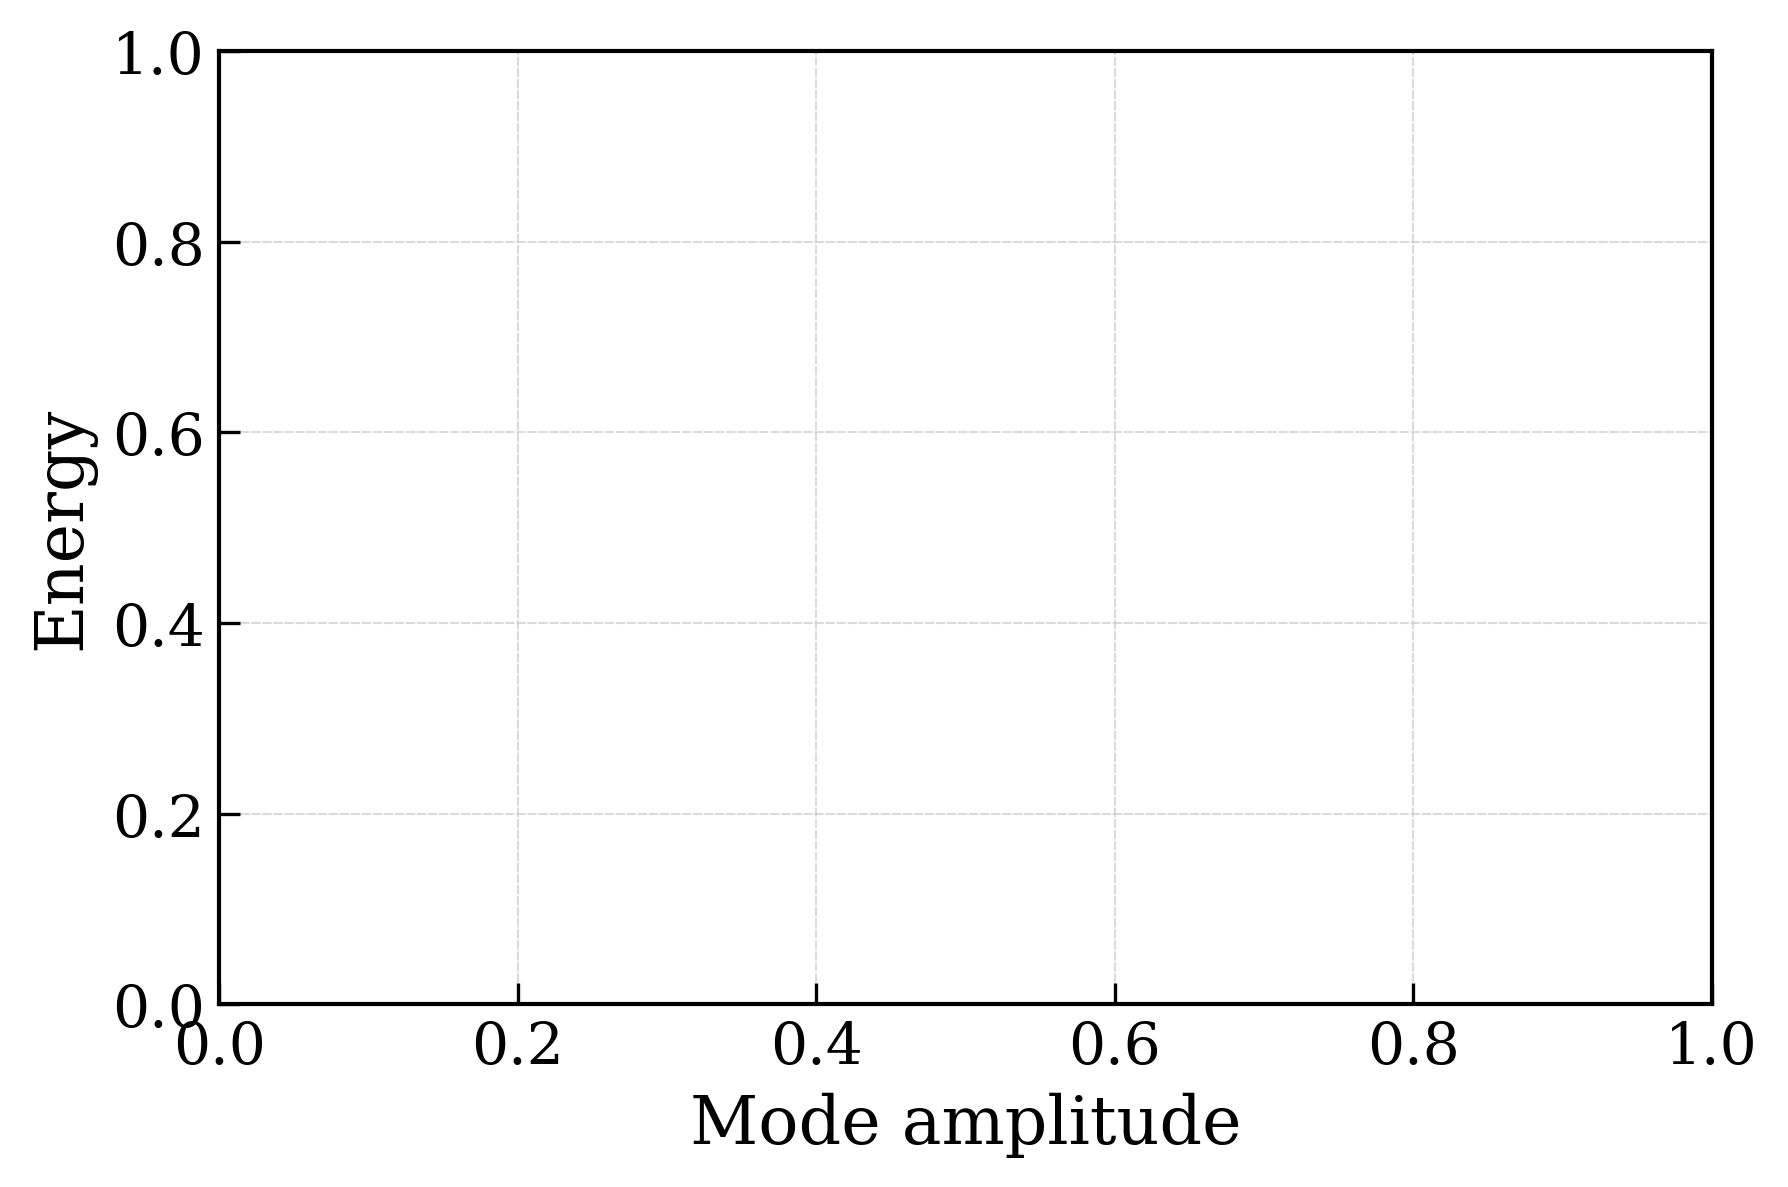

In [41]:
for (angle, phi1, phi2), (configs, energies, curv) in results.items():
    curv = curvature(mode_amplitudes, energies)
    print(curv)
    results[(angle, phi1, phi2)] = (configs, energies, curv)

for (angle, phi1, phi2), (configs, energies, curv) in results.items():
    if curv < 0:
        print("Negative curvature", curv, f" for angle={angle:.2f}, phi1={phi1:.2f}, phi2={phi2:.2f}")
        plt.plot(mode_amplitudes, energies, label=f"angle={angle:.2f}, phi1={phi1:.2f}, phi2={phi2:.2f}")

plt.xlabel("Mode amplitude")
plt.ylabel("Energy")
plt.grid(True)
# plt.legend(loc = "lower left")
plt.tight_layout()
plt.show()

In [42]:
results.keys()

dict_keys([(0.7853981633974483, 0, np.float64(0.0)), (0.7853981633974483, 0, np.float64(0.03510159389485802)), (0.7853981633974483, 0, np.float64(0.07020318778971604)), (0.7853981633974483, 0, np.float64(0.10530478168457406)), (0.7853981633974483, 0, np.float64(0.14040637557943209)), (0.7853981633974483, 0, np.float64(0.1755079694742901)), (0.7853981633974483, 0, np.float64(0.21060956336914813)), (0.7853981633974483, 0, np.float64(0.24571115726400616)), (0.7853981633974483, 0, np.float64(0.28081275115886417)), (0.7853981633974483, 0, np.float64(0.3159143450537222)), (0.7853981633974483, 0, np.float64(0.3510159389485802)), (0.7853981633974483, 0, np.float64(0.38611753284343825)), (0.7853981633974483, 0, np.float64(0.42121912673829626)), (0.7853981633974483, 0, np.float64(0.45632072063315426)), (0.7853981633974483, 0, np.float64(0.4914223145280123)), (0.7853981633974483, 0, np.float64(0.5265239084228703)), (0.7853981633974483, 0, np.float64(0.5616255023177283)), (0.7853981633974483, 0, n

In [43]:
view(results[(0.7853981633974483, 0, 0)][0][:], viewer="ngl")

(-5.0, 9.0)

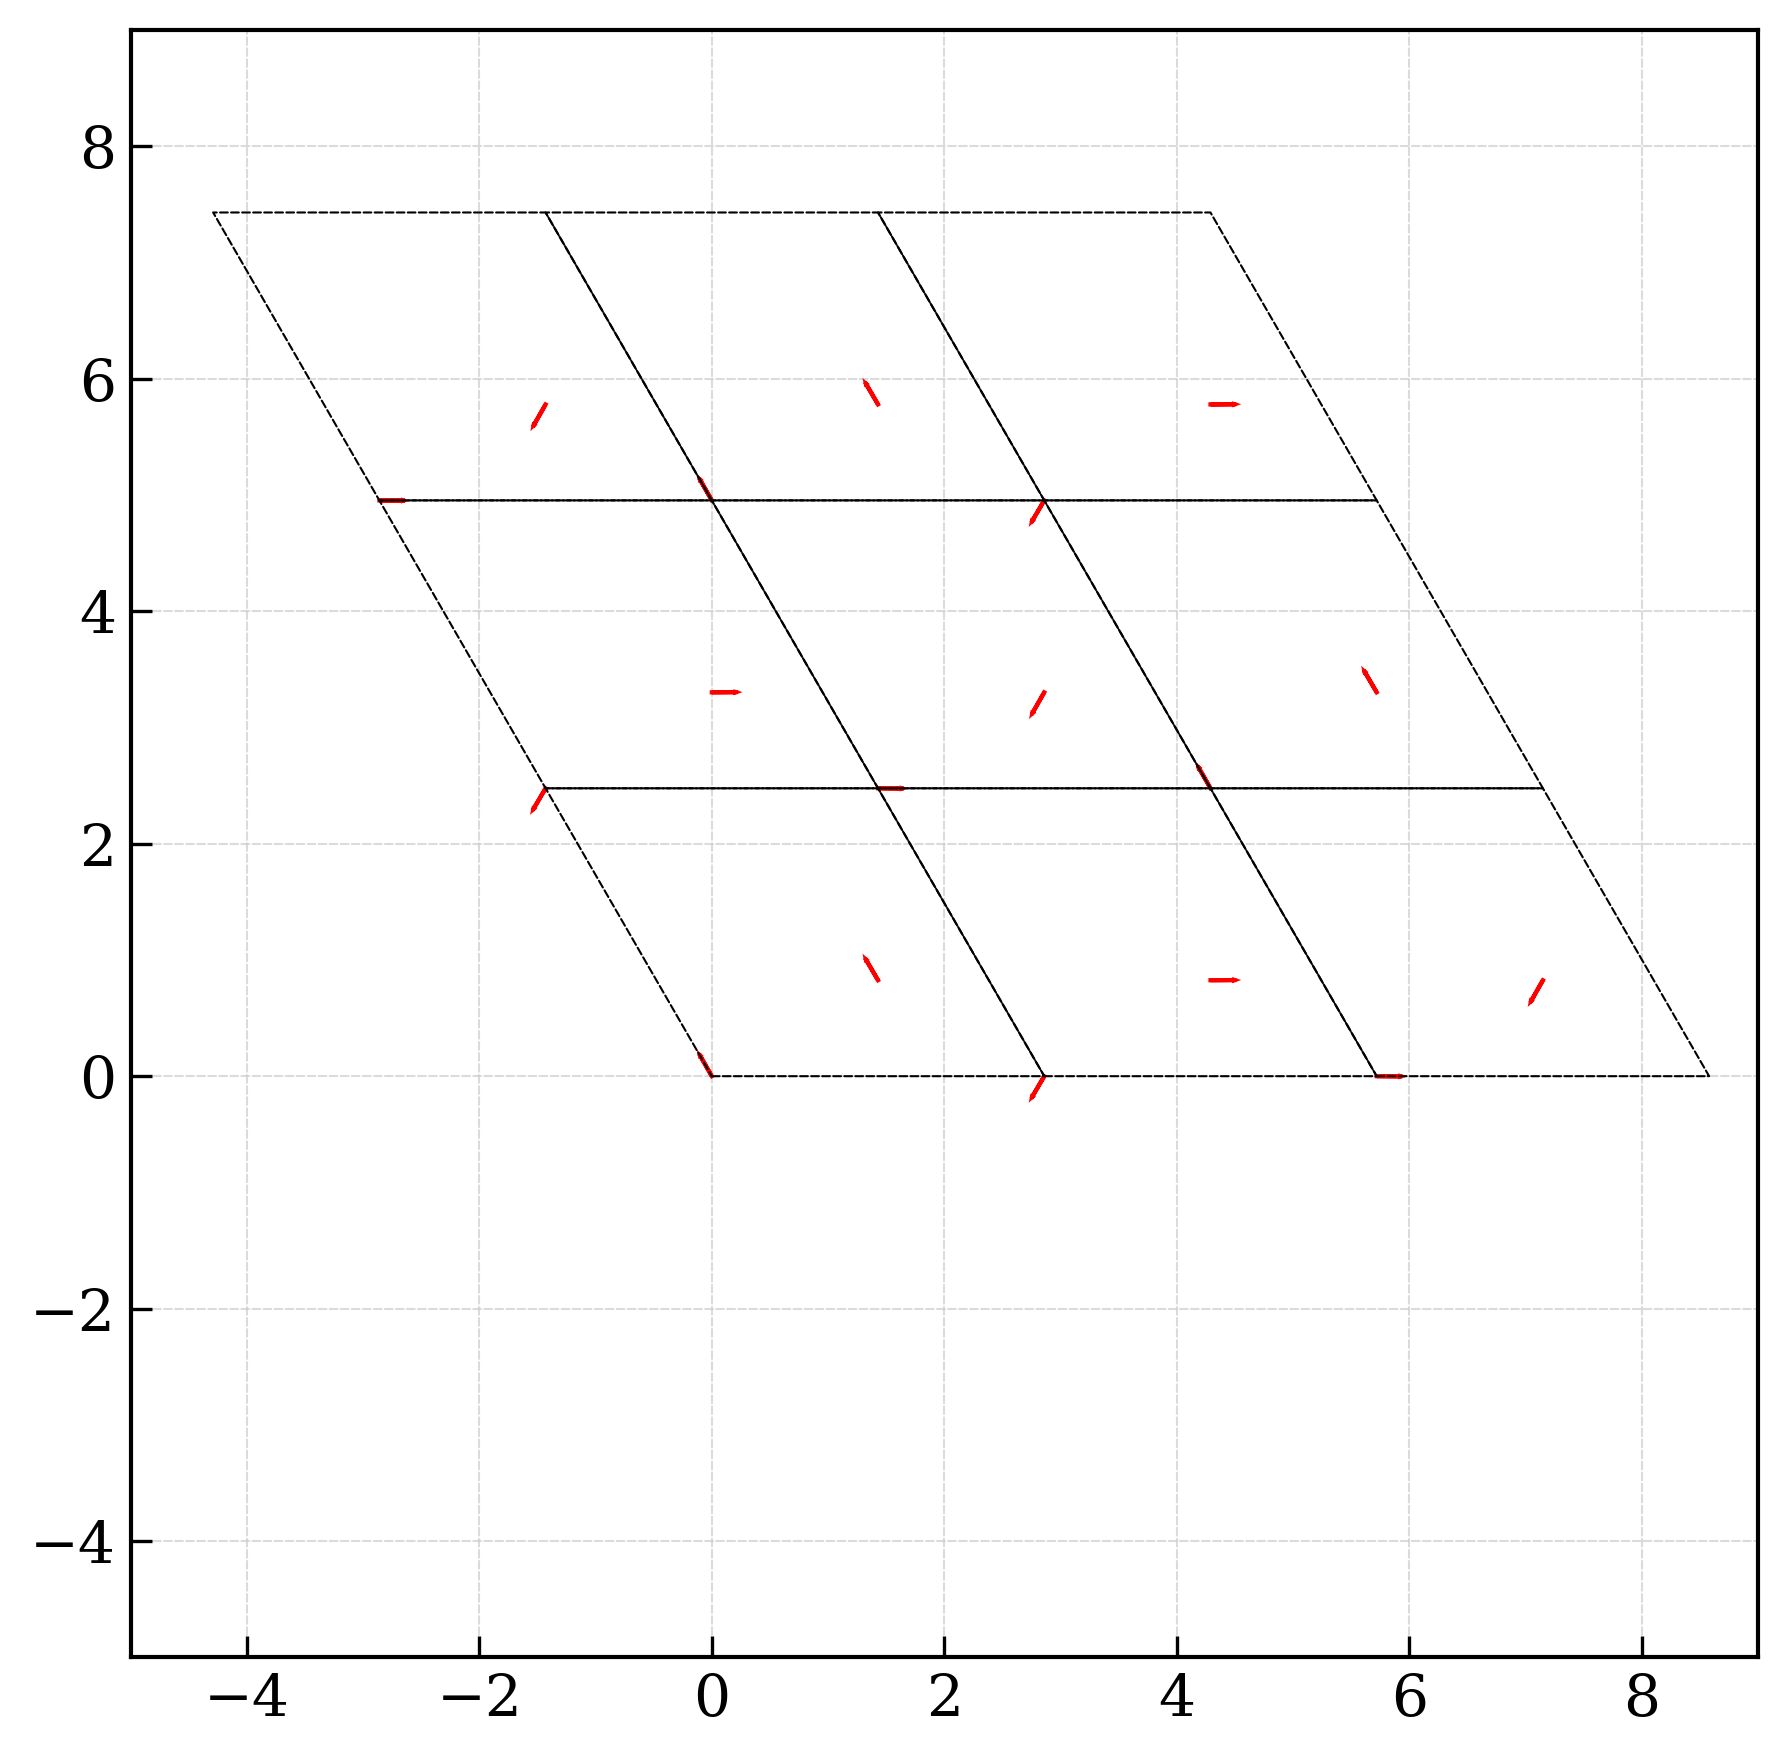

In [51]:
displacements =( results[(0.7853981633974483, 0, 0)][0][-1].positions - results[(0.7853981633974483, 0, 0)][0][0].positions)*10

fig, ax = plt.subplots(figsize=(6,6))
for pos, displacement in zip((deformed_primitive * (3, 3, 1)).positions, displacements):
    plt.arrow(pos[0], pos[1], displacement[0], displacement[1], color="r")

# draw tesselation of supercell in primitive cells
for i in range(3):
    for j in range(3):
        cell_origin = i * deformed_primitive.cell[0] + j * deformed_primitive.cell[1]
        cell_corners = [
            cell_origin,
            cell_origin + deformed_primitive.cell[0],
            cell_origin + deformed_primitive.cell[0] + deformed_primitive.cell[1],
            cell_origin + deformed_primitive.cell[1],
            cell_origin
        ]
        cell_corners = np.array(cell_corners)
        plt.plot(cell_corners[:, 0], cell_corners[:, 1], color="k", linestyle="--", linewidth=0.5)


ax.set_aspect("equal")
plt.xlim(-5, 9)
plt.ylim(-5, 9)

[ 3.09592042e-01  8.44194265e-02  8.44182615e+00 -2.68905039e-05
 -1.19923472e+02]


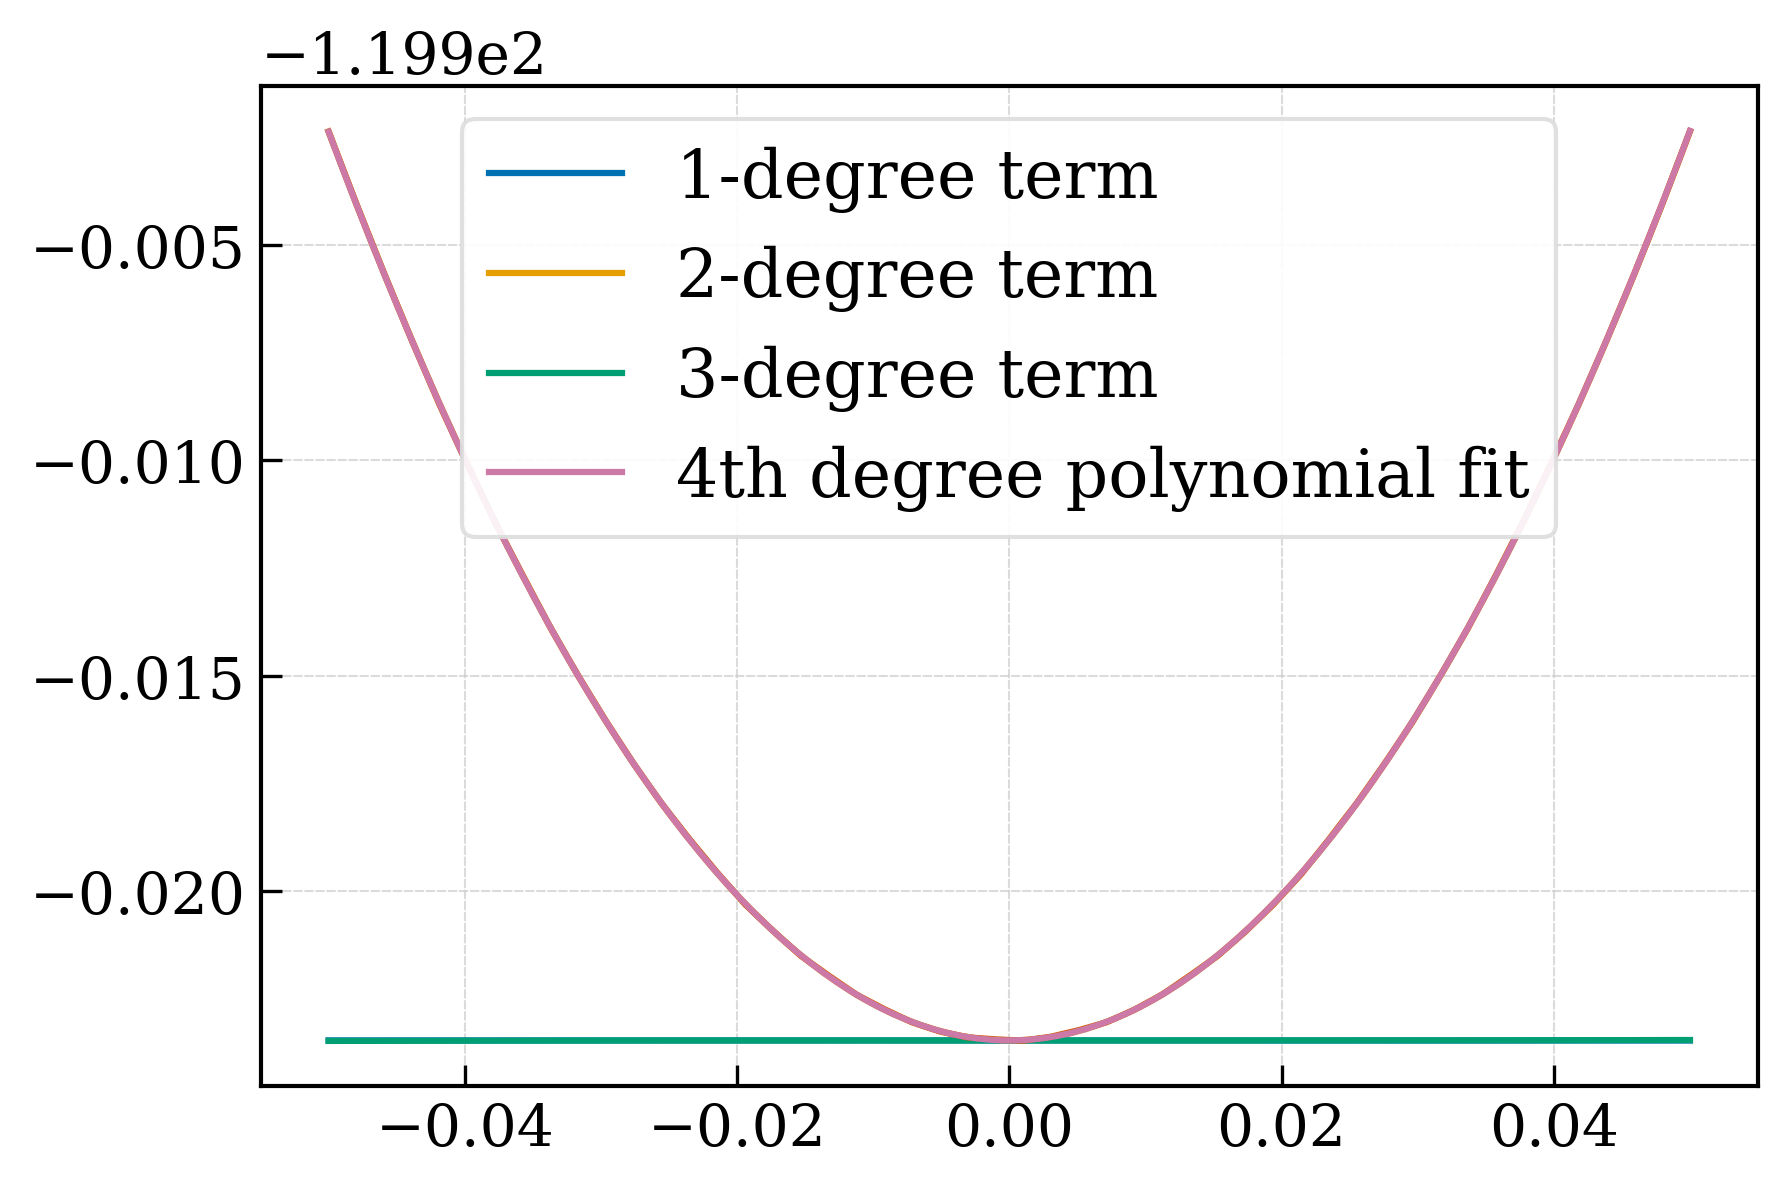

In [159]:
from numpy import polyfit, polyval

coeffs = np.polyfit(mode_amplitudes, results[(0.7853981633974483, 0, 0)][1], deg=4)
support = np.linspace(mode_amplitudes[0], mode_amplitudes[-1], 100)
fitted_curve = polyval(coeffs, support)

for degree in range(1, 4):
    ys = coeffs[-(degree+1)] * support**degree + coeffs[-1]
    plt.plot(support, ys, label=f"{degree}-degree term")

plt.plot(mode_amplitudes, results[(0.7853981633974483, 0, 0)][1])

plt.plot(support, fitted_curve, label="4th degree polynomial fit")

print(coeffs)
plt.legend()

In [160]:
coeffs[-3]

np.float64(8.441826154167698)

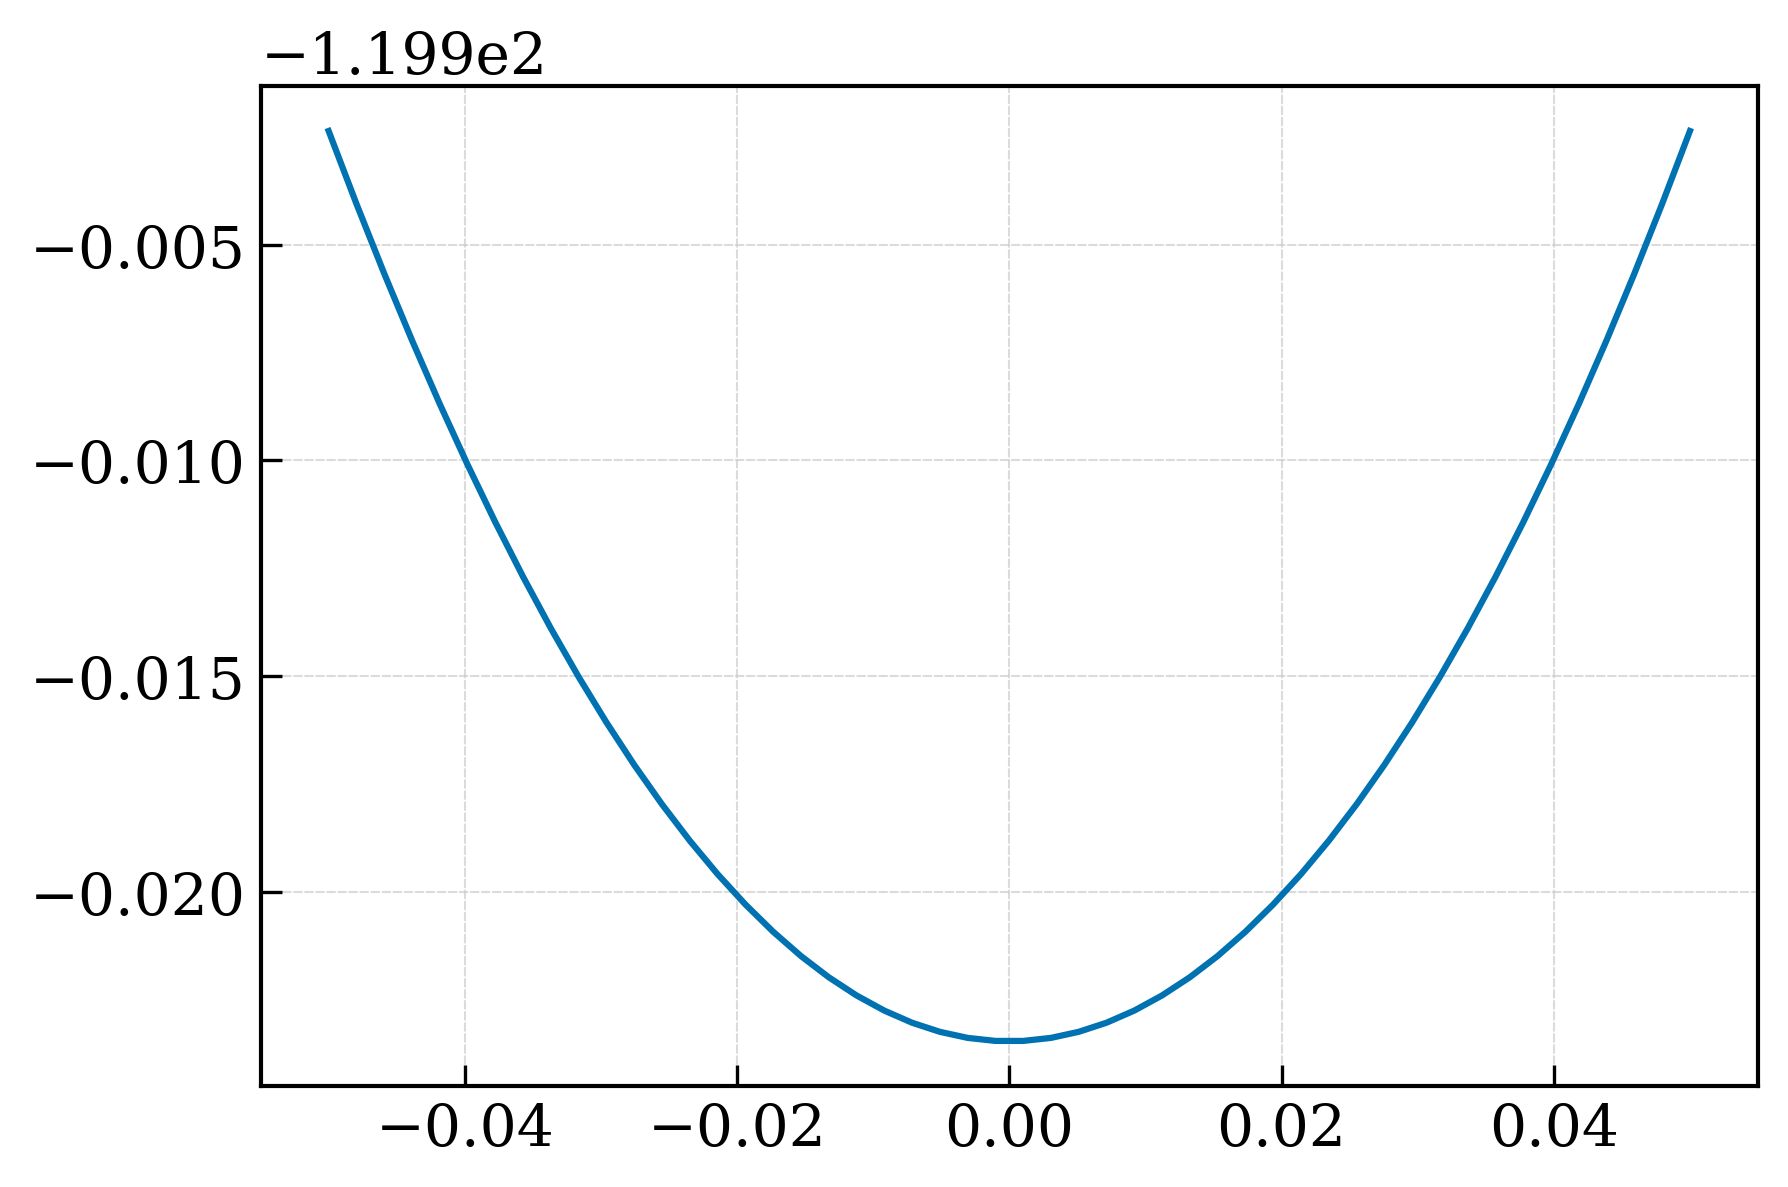

In [161]:
plt.plot(mode_amplitudes, coeffs[-1] + coeffs[-3]*mode_amplitudes**2 )

In [ ]:
for (angle, phi1, phi2), (configs, energies) in results.items():
    plt.plot(mode_amplitudes, energies, label=f"angle={angle:.2f}, phi1={phi1:.2f}, phi2={phi2:.2f}")
    plt.xlabel("Mode amplitude")
    plt.ylabel("Energy")
    plt.grid(True)
    plt.legend()


In [ ]:
results_finer = {}

for angle in tqdm(np.linspace(0, np.pi/2, 5), total=5):
    for phi1 in np.linspace(0, np.pi, 5):
        for phi2 in np.linspace(0, np.pi, 5):
            coefficients = np.array([np.cos(angle) * np.exp(1j * phi1), np.sin(angle) * np.exp(1j * phi2)])

            configs, energies, _ = energy_mode(
                graphene_pristine, 
                strain_versor, 
                strain_amplitude, 
                np.diag([3, 3, 1]),
                model,
                np.array([k1, k2]),
                np.array([mode1, mode2]),
                coefficients,
                mode_amplitudes
            )
            
            results_finer[(angle, phi1, phi2)] = (configs, energies)


In [41]:
mode1 + mode2

array([[-2.20688929e-01+0.j,  1.85884744e-01+0.j, -1.28928418e-05+0.j],
       [-5.06660441e-02+0.j,  2.84054417e-01+0.j,  3.09272832e-06+0.j]])

In [42]:
angle = 45
rot = 0
amplitude = 0.23

C = np.cos(angle * DEG2RAG)
S = np.sin(angle * DEG2RAG)

Cr = np.cos(rot * DEG2RAG)
Sr = np.sin(rot * DEG2RAG)

ROT = np.array([
    [Cr, -Sr, 0],
    [Sr, Cr, 0],
    [0, 0, 1]
])

strain_versor = np.array([
    [C, 0, 0],
    [0, S, 0],
    [0, 0, 0]
])
strain = amplitude * strain_versor
deformation = np.eye(3) + strain

deformed_primitive = graphene_pristine.copy()
deformed_primitive.calc = model

opt = BFGS(deformed_primitive)
opt.run(1e-5)

deformed_primitive.set_cell(deformed_primitive.cell @ deformation, scale_atoms=True)

      Step     Time          Energy          fmax
BFGS:    0 12:31:13      -15.917213        0.000003


In [43]:
deformed_primitive.cell

Cell([[2.8598822464563924, 0.0, 0.0], [-1.4299411232281962, 2.4767305851433328, 0.0], [0.0, 0.0, 100.0]])

In [44]:
view(deformed_primitive, viewer="ngl")

<Axes3D: >

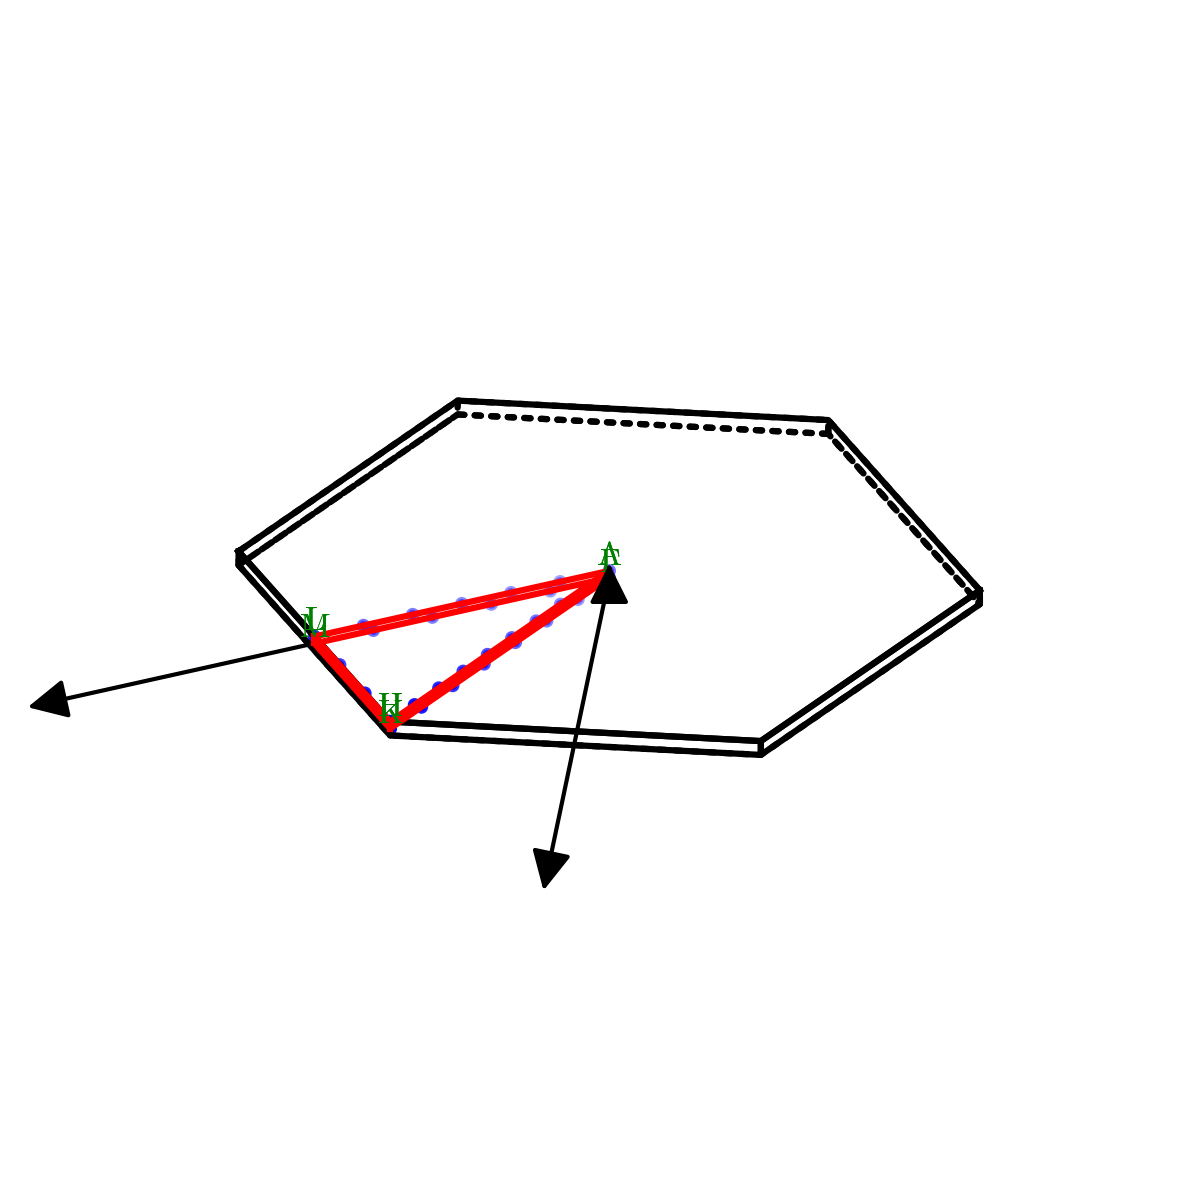

In [45]:
deformed_primitive.cell.bandpath().plot()

In [46]:
deformed_primitive.cell.bandpath().cell

Cell([[1.4299411232281962, -2.4767306772633444, 0.0], [1.4299411232281962, 2.4767306772633444, 0.0], [0.0, 0.0, 100.0]])

In [47]:
ph = Phonons(
    deformed_primitive,
    model,
    supercell = (9, 9, 1),
    delta = 0.01,
    name="cache"
)

np.printoptions(precision=16, floatmode="fixed")

from ase.io import write
write("deformed_primitive.extxyz", deformed_primitive)
print("="*70)
print("deformed positions")
print(np.array(deformed_primitive.positions))

ph.run()
ph.read(acoustic=True)
ph.clean()

deformed positions
[[-1.40017951e-09  8.17541099e-08 -1.12578097e-21]
 [ 1.42994112e+00  8.25576780e-01 -3.43512249e-22]]


13

In [48]:
from ase.dft.kpoints import BandPath

k1 = np.array([1/3., 1/3., 0])
k2 = -k1

bs, modes = ph.band_structure([k1, k2], modes = True)

WARNING, 1 imaginary frequencies at q = ( 0.33,  0.33,  0.00) ; (omega_q = 1.809e-01*i)
WARNING, 1 imaginary frequencies at q = (-0.33, -0.33, -0.00) ; (omega_q = 1.809e-01*i)


In [49]:
modes[1][0] + modes[0][0]

array([[-2.11340856e-01+0.j, -1.96457749e-01+0.j, -1.14398407e-05+0.j],
       [ 2.75814817e-01+0.j,  8.47939712e-02+0.j, -2.14906743e-05+0.j]])

In [50]:
mode_amplitudes = np.linspace(-0.5, 0.5, 50)

strained positions
[[-1.40017951e-09  8.17541099e-08 -1.12578097e-21]
 [ 1.42994112e+00  8.25576780e-01 -3.43512249e-22]]
fractional positions
[[ 1.60148480e-08  3.30088829e-08 -1.12578097e-23]
 [ 6.66666649e-01  3.33333300e-01 -3.43512249e-24]]
R_cN
[[0 0 0 1 1 1 2 2 2]
 [0 1 2 0 1 2 0 1 2]
 [0 0 0 0 0 0 0 0 0]]
phase_Na
[ 1. +0.00000000e+00j  1. +0.00000000e+00j -0.5+8.66025404e-01j
 -0.5+8.66025404e-01j -0.5-8.66025404e-01j -0.5-8.66025404e-01j
 -0.5+8.66025404e-01j -0.5+8.66025404e-01j -0.5-8.66025404e-01j
 -0.5-8.66025404e-01j  1. -2.44929360e-16j  1. -2.44929360e-16j
 -0.5-8.66025404e-01j -0.5-8.66025404e-01j  1. -2.44929360e-16j
  1. -2.44929360e-16j -0.5+8.66025404e-01j -0.5+8.66025404e-01j]
phase_Na
[ 1. +0.00000000e+00j  1. +0.00000000e+00j -0.5-8.66025404e-01j
 -0.5-8.66025404e-01j -0.5+8.66025404e-01j -0.5+8.66025404e-01j
 -0.5-8.66025404e-01j -0.5-8.66025404e-01j -0.5+8.66025404e-01j
 -0.5+8.66025404e-01j  1. +2.44929360e-16j  1. +2.44929360e-16j
 -0.5+8.66025404e-01j -0.5

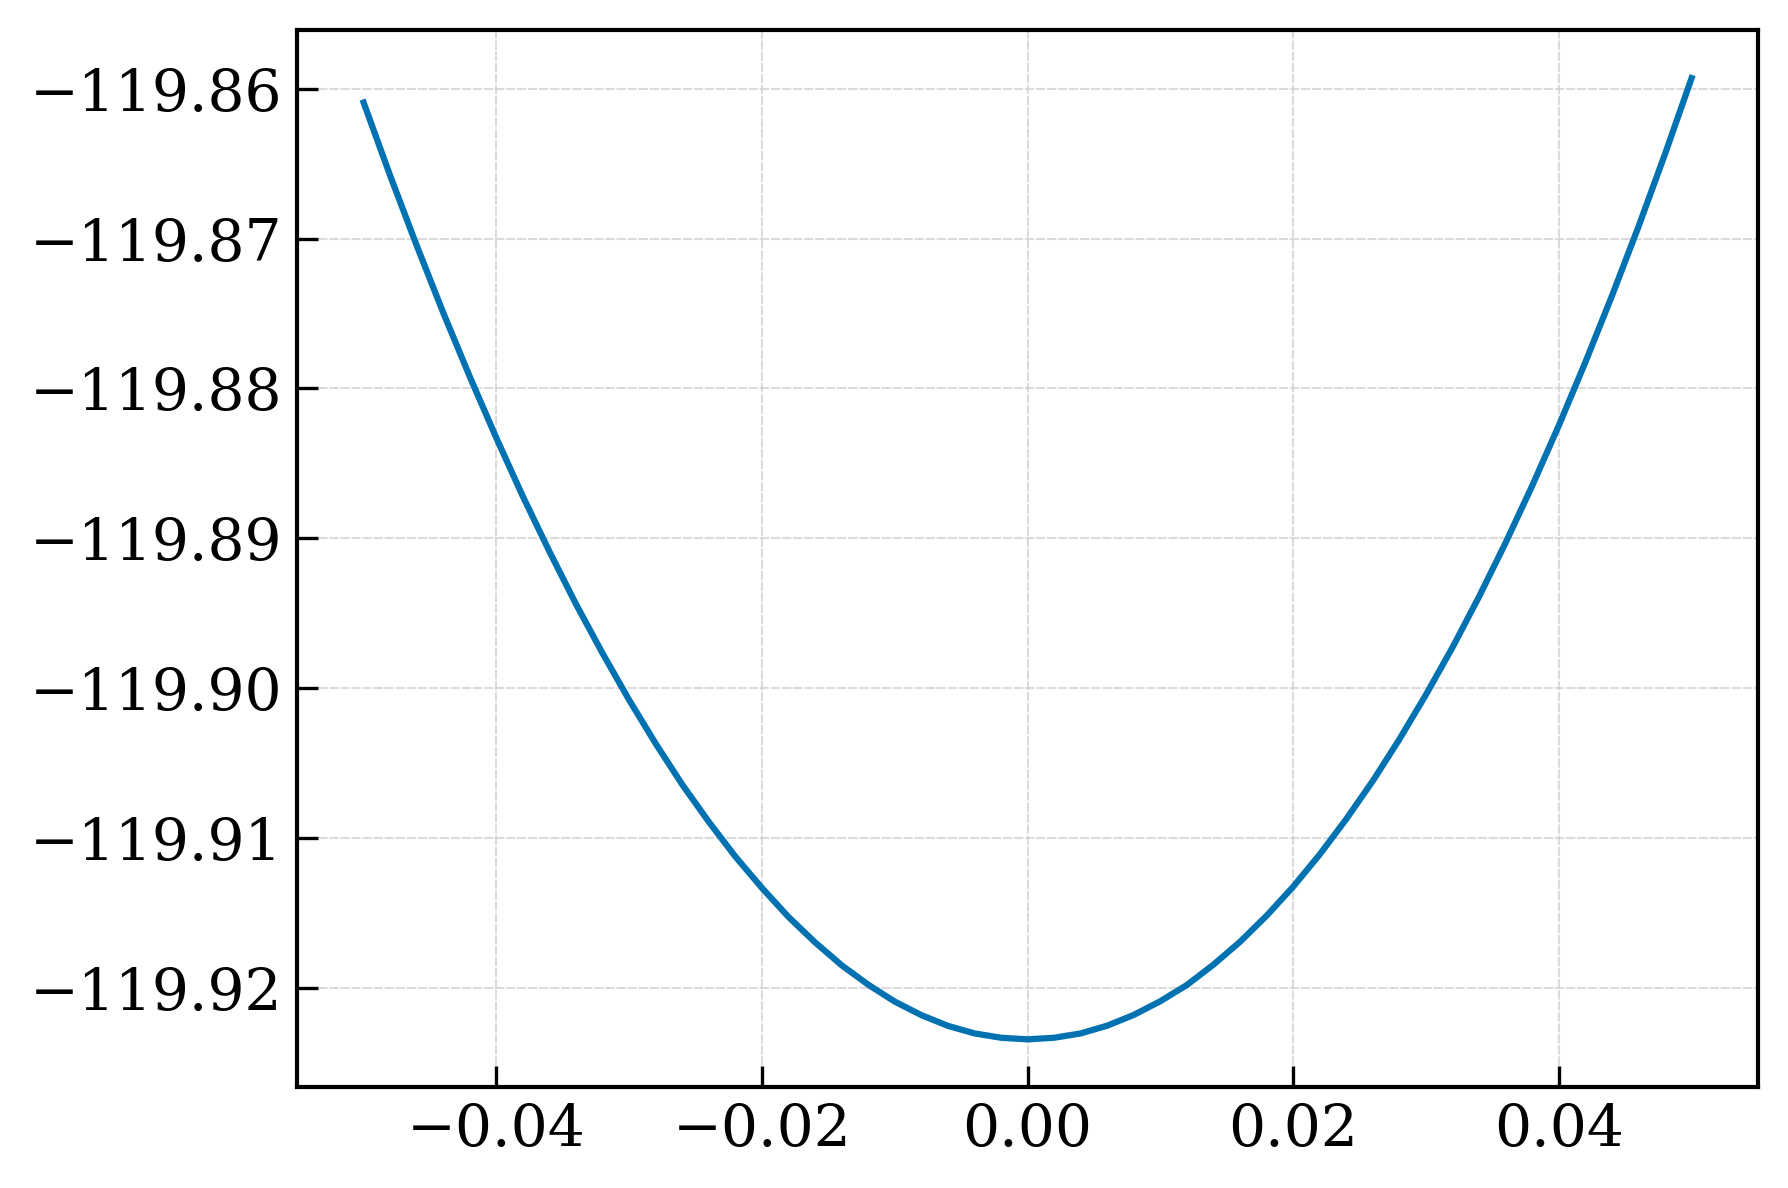

In [55]:
amplitudes = np.linspace(-0.05, 0.05, 51, True)

phonon_images, energies, force_projections = energy_mode(
                            graphene_pristine, 
                            versor=strain_versor, 
                            amplitude = amplitude,
                            supercell = (3, 3, 1),
                            calc = model,
                            kpoints = np.array([k1, k2]),
                            modes = np.array([modes[0][0] / np.linalg.norm(modes[0][0]), modes[1][0] / np.linalg.norm(modes[1][0])]),
                            coefficients = np.array([1, 1]) / np.sqrt(2),
                            mode_amplitudes=amplitudes,
                            phase_shift= - 4*np.pi/3
                        )

plt.plot(amplitudes, energies)

In [52]:
force_projections = np.array(force_projections)
print(force_projections.shape)

(51, 18, 3)


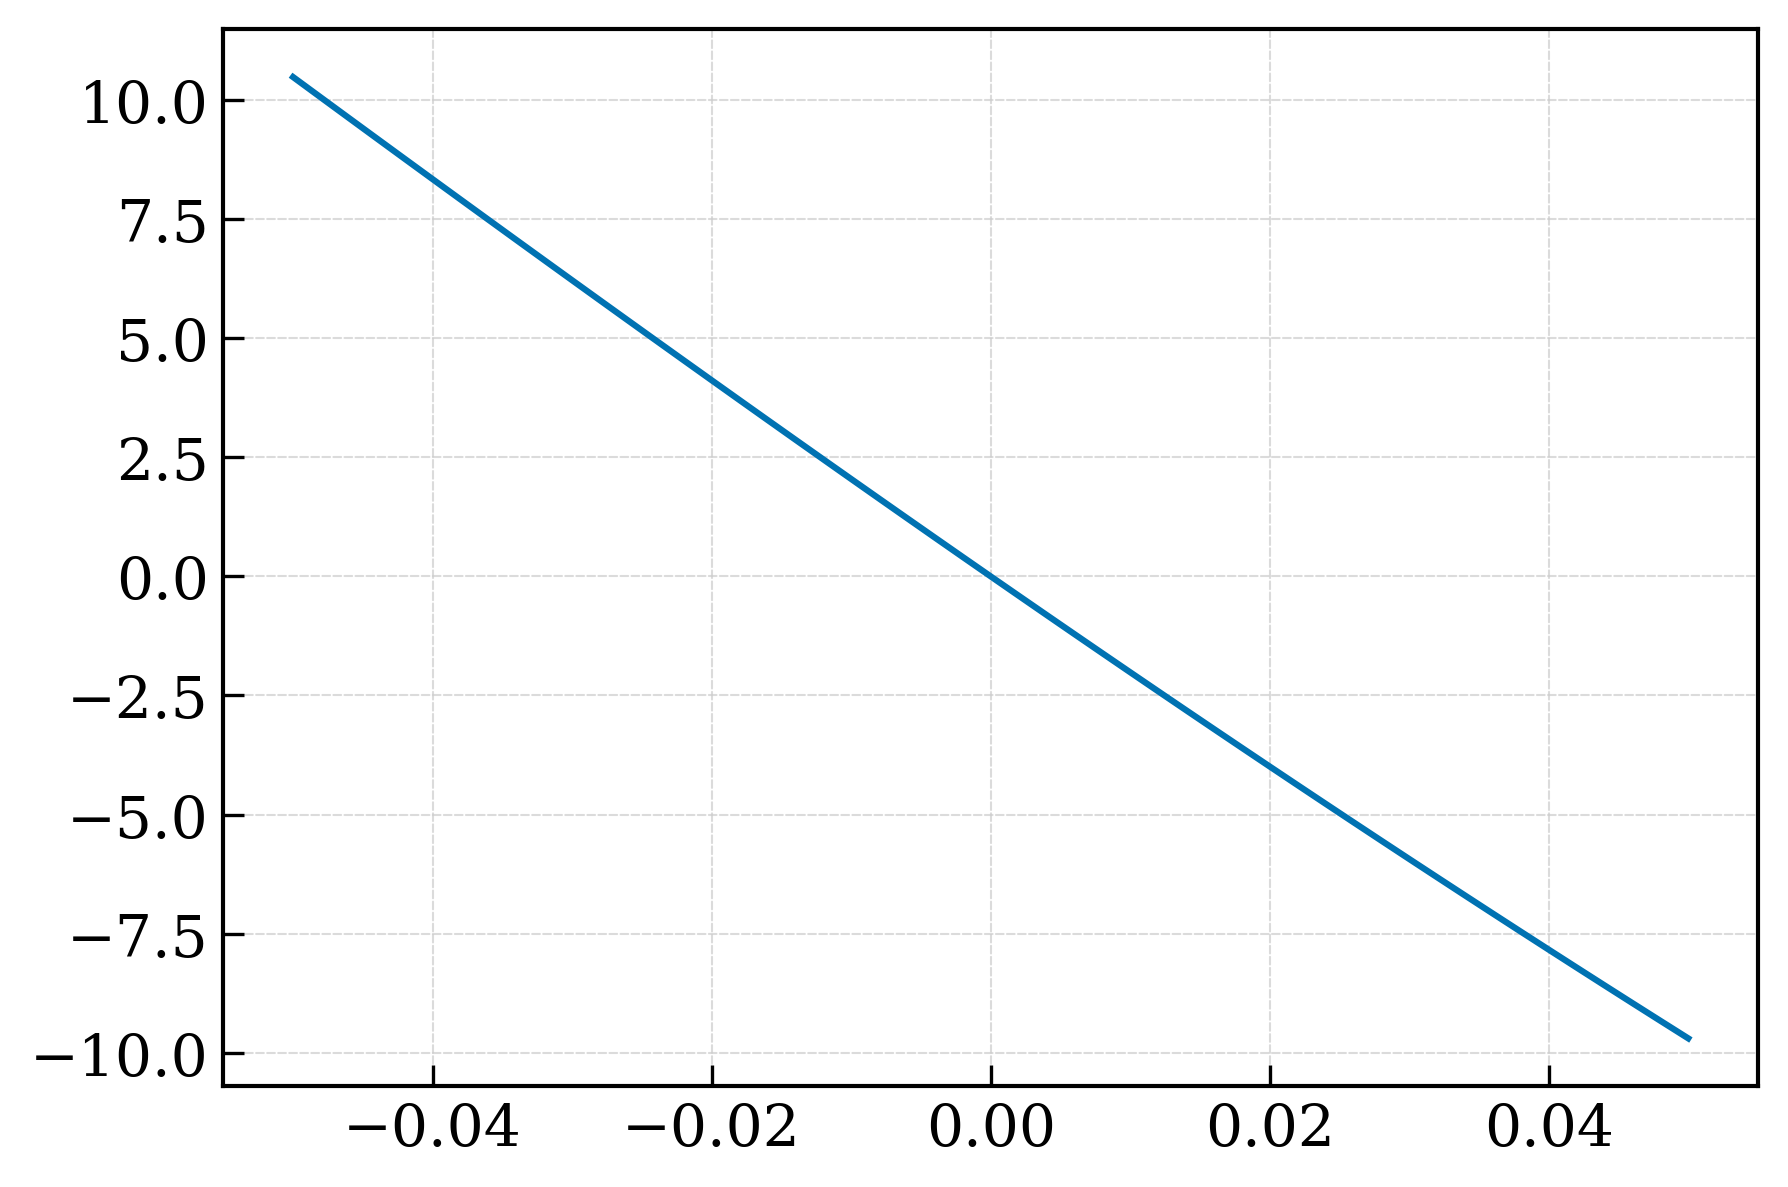

In [53]:
plt.plot(amplitudes, np.sum(force_projections, axis = (1, 2)))

In [54]:
view(phonon_images, viewer = "ngl")

In [201]:
D_k1 = ph.compute_dynamical_matrix(k1, ph.D_N)
eigenvals1, eigenvects1 = np.linalg.eigh(D_k1, UPLO="U")
eigenvects1 = (
                    ph.m_inv_x[:, np.newaxis] * eigenvects1[:, eigenvals1.argsort()]
                ).T.copy().reshape((-1, len(ph.indices), 3))

D_k2 = ph.compute_dynamical_matrix(k2, ph.D_N)
eigenvals2, eigenvects2 = np.linalg.eigh(D_k2, UPLO="U")
eigenvects2 = (
                    ph.m_inv_x[:, np.newaxis] * eigenvects2[:, eigenvals2.argsort()]
                ).T.copy().reshape((-1, len(ph.indices), 3))

In [202]:
D_k1.shape

(6, 6)

In [203]:
(1/ph.m_inv_x)**2

array([12.011, 12.011, 12.011, 12.011, 12.011, 12.011])

In [204]:
import numpy as np

m_inv_matrix = ph.m_inv_x.reshape(len(ph.indices), 3)

# Find the absolute minimum eigenvalue
idx1 = np.argmin(eigenvals1)
idx2 = np.argmin(eigenvals2)

print(" Eigenvalue Verification ")
print(f"Lowest omega^2 at K:  {eigenvals1[idx1]:.6f}")
print(f"Lowest omega^2 at -K: {eigenvals2[idx2]:.6f}")

# Extract the eigenvectors
u1 = eigenvects1[idx1] # shape (2, 3)
u2 = eigenvects2[idx2] # shape (2, 3)

print("\n Eigenmode Solver Equation Check ")
# Reconstruct the flat 3N vectors to multiply against the 6x6 Dynamical Matrix
# To undo the mass weighting: v_flat = (u / m_inv)
u1_flat_unweighted = (u1 / m_inv_matrix**2).flatten()

# D * v
lhs1 = D_k1 @ u1_flat_unweighted
# lambda * v
rhs1 = eigenvals1[idx1] * u1_flat_unweighted

error = np.linalg.norm(lhs1 - rhs1)
print(f"Dynamical Matrix Solver Error: {error:.6e}")

 Eigenvalue Verification 
Lowest omega^2 at K:  -0.032788
Lowest omega^2 at -K: -0.032788

 Eigenmode Solver Equation Check 
Dynamical Matrix Solver Error: 1.443768e-05


Targeting unstable mode at K (Index 0): omega^2 = -0.0328
Targeting unstable mode at -K (Index 0): omega^2 = -0.0328
      Step     Time          Energy          fmax
BFGS:    0 16:55:38      -13.324829        0.000002
strained positions
[[-1.06729233e-08  4.82751503e-08 -5.09329347e-22]
 [ 1.42994104e+00  8.25576810e-01 -2.87108133e-22]]


/tmp/ipykernel_11183/604914607.py:36: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


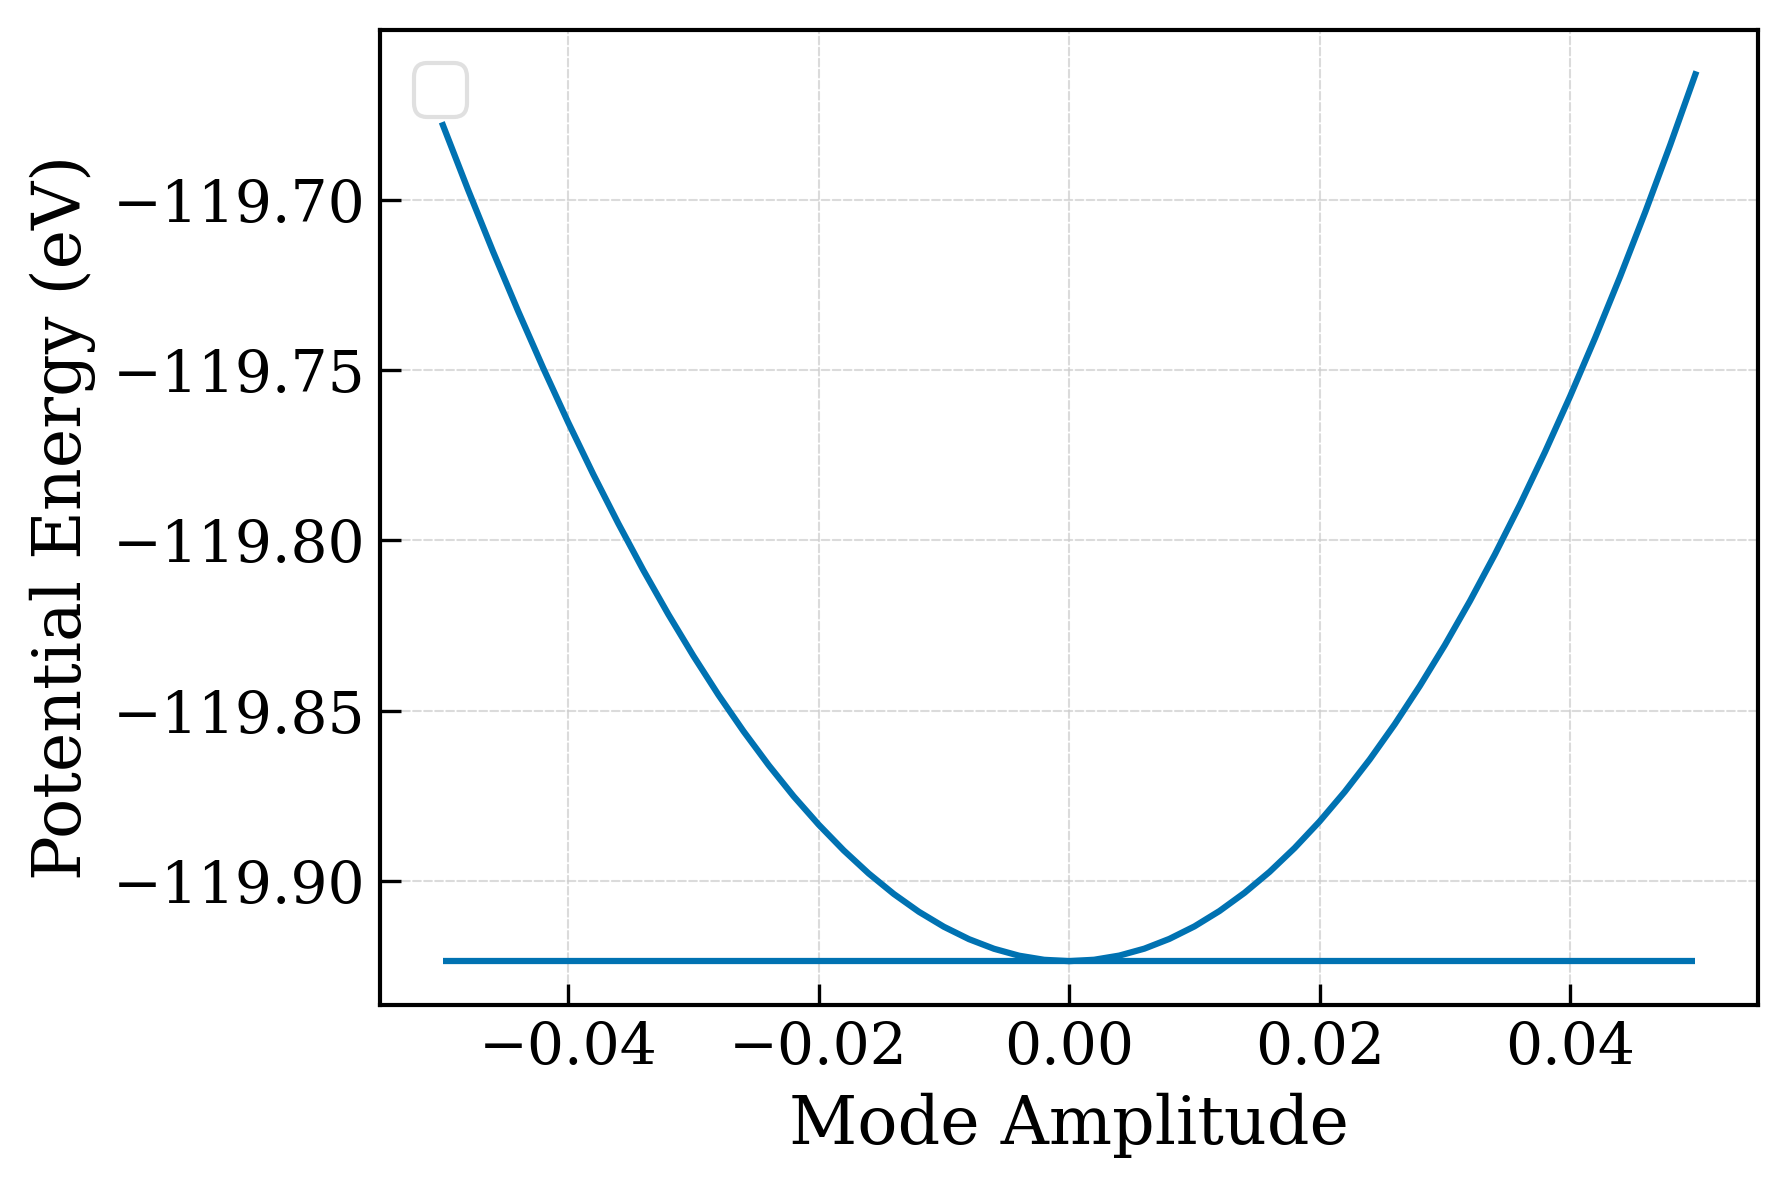

In [205]:
# 1. Dynamically locate the index of the true structural instability (most negative omega^2)
idx_unstable_1 = np.argmin(eigenvals1)
idx_unstable_2 = np.argmin(eigenvals2)

# Double check that the targeted eigenvalues are actually negative
print(f"Targeting unstable mode at K (Index {idx_unstable_1}): omega^2 = {eigenvals1[idx_unstable_1]:.4f}")
print(f"Targeting unstable mode at -K (Index {idx_unstable_2}): omega^2 = {eigenvals2[idx_unstable_2]:.4f}")

# 2. Extract and independently normalize the CORRECT unstable eigenvectors
u1_unstable = eigenvects1[idx_unstable_1] / np.linalg.norm(eigenvects1[idx_unstable_1])
u2_unstable = eigenvects2[idx_unstable_2] / np.linalg.norm(eigenvects2[idx_unstable_2])

# 3. Feed the genuine unstable optical eigenvectors into your energy mapper
amplitudes = np.linspace(-0.05, 0.05, 51, True)

phonon_images, energies, force_projections = energy_mode(
    graphene_pristine, 
    versor=strain_versor, 
    amplitude=amplitude,
    supercell=(3, 3, 1),
    calc=model,
    kpoints=np.array([k1, k2]),
    modes=np.array([u1_unstable, u2_unstable]),
    coefficients=np.array([1, 1]) / np.sqrt(2),
    mode_amplitudes=amplitudes,
)

deformed_primitive.calc = model
e0 = deformed_primitive.get_potential_energy() * np.prod([3, 3, 1])
plt.hlines(e0, amplitudes[0], amplitudes[-1])

# Plotting the guaranteed double-well potential
plt.plot(amplitudes, energies)
plt.xlabel("Mode Amplitude")
plt.ylabel("Potential Energy (eV)")
plt.legend()
plt.show()

In [206]:
view(phonon_images, viewer = "ngl")

/home/gabrielecolombo/Thesis/PROJECT/.venv/lib/python3.12/site-packages/matplotlib/cbook.py:1719: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)


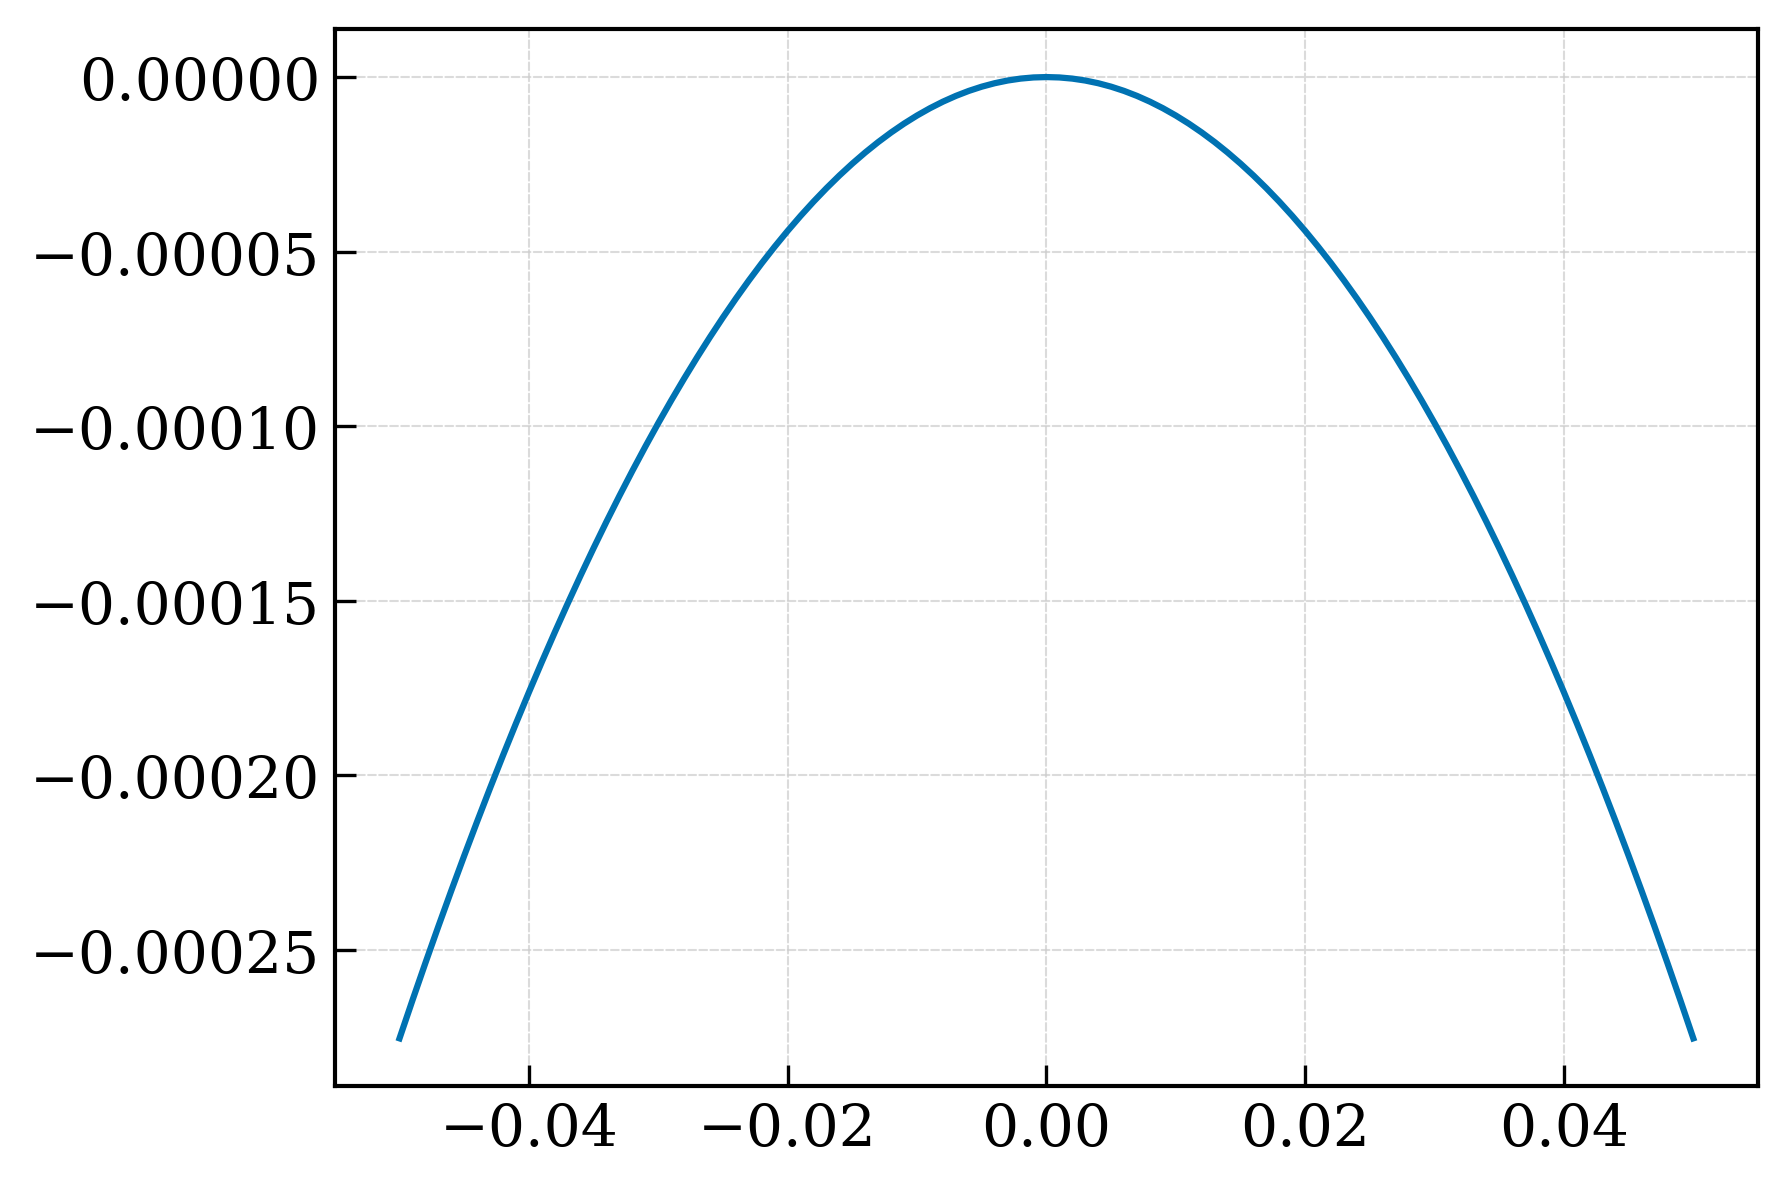

In [207]:
phasek = 3 * (1 + np.exp(1j * 4*np.pi/3) + np.exp(1j + 2*np.pi/3))
mass = 12.011
ncells = 9
w2 = eigenvals1[0]**2

amps_testing = np.linspace(-0.05, 0.05, 101)

es_testing = - mass * w2 * amps_testing**2 *(
    ncells * np.sum(u1_unstable.conj() * u1_unstable) + 
    np.real(phasek * np.sum(eigenvects1**2))
)

plt.plot(amps_testing, es_testing)

In [208]:
es_testing

array([-2.75400682e-04-1.80992838e-21j, -2.64494815e-04-1.73825521e-21j,
       -2.53809268e-04-1.66802999e-21j, -2.43344042e-04-1.59925271e-21j,
       -2.33099137e-04-1.53192338e-21j, -2.23074552e-04-1.46604198e-21j,
       -2.13270288e-04-1.40160853e-21j, -2.03686344e-04-1.33862303e-21j,
       -1.94322721e-04-1.27708546e-21j, -1.85179418e-04-1.21699584e-21j,
       -1.76256436e-04-1.15835416e-21j, -1.67553775e-04-1.10116042e-21j,
       -1.59071434e-04-1.04541463e-21j, -1.50809413e-04-9.91116778e-22j,
       -1.42767713e-04-9.38266870e-22j, -1.34946334e-04-8.86864904e-22j,
       -1.27345275e-04-8.36910881e-22j, -1.19964537e-04-7.88404800e-22j,
       -1.12804119e-04-7.41346663e-22j, -1.05864022e-04-6.95736467e-22j,
       -9.91442455e-05-6.51574215e-22j, -9.26447894e-05-6.08859905e-22j,
       -8.63656538e-05-5.67593538e-22j, -8.03068388e-05-5.27775114e-22j,
       -7.44683444e-05-4.89404633e-22j, -6.88501705e-05-4.52482094e-22j,
       -6.34523171e-05-4.17007498e-22j, -5.82747843

In [209]:
ph.write_modes(k1, 0, 1e-1, repeat = (9, 9, 1), nimages = 100)

WARNING, 1 imaginary frequencies at q = ( 0.33,  0.33,  0.00) ; (omega_q = 1.811e-01*i)


In [210]:
phonon_mode = Trajectory("cache.mode.0.traj")

In [211]:
et = []
for image in phonon_mode:
    image.calc = model
    et.append(image.get_potential_energy())

In [212]:
graphene_pristine.calc = model
eref = deformed_primitive.get_potential_energy() * np.prod((9, 9,1))

In [213]:
deformed_primitive.get_potential_energy()

-13.3248291015625

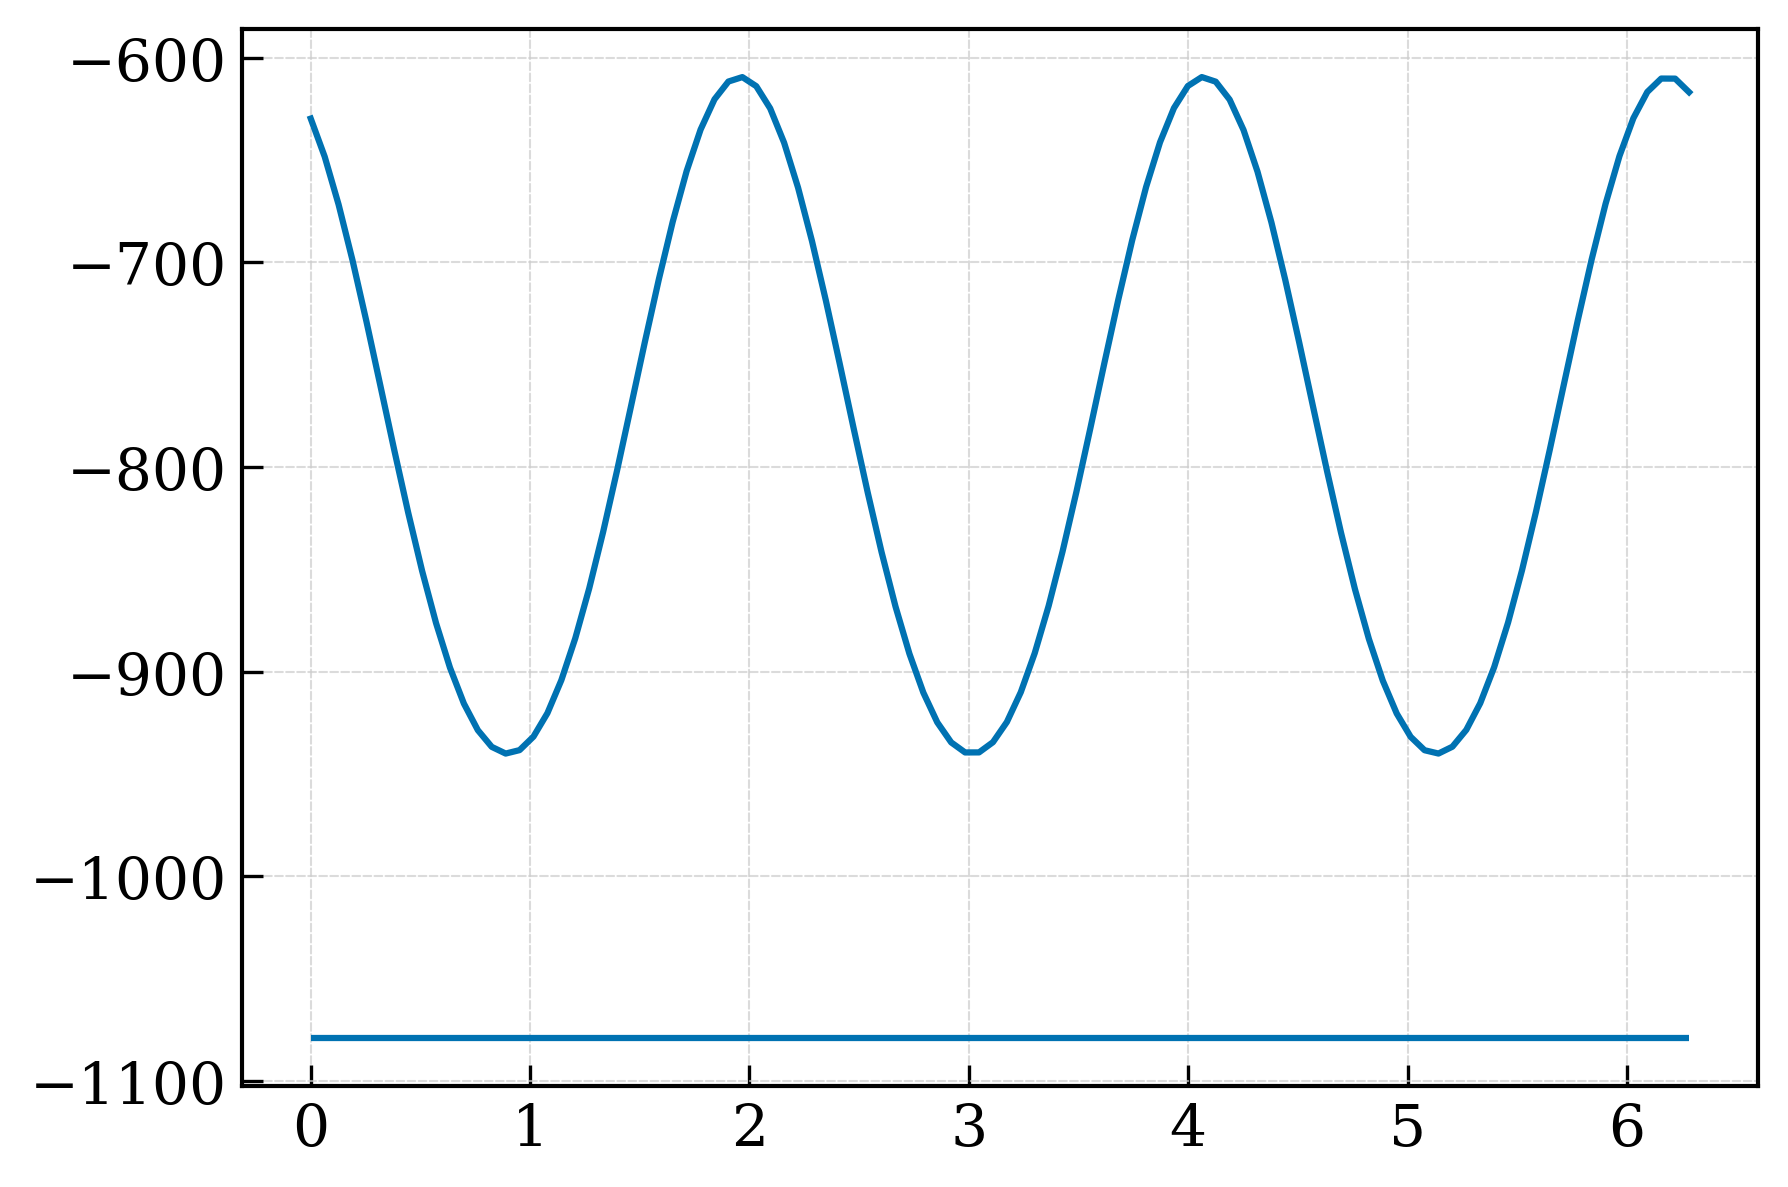

In [214]:
phases = np.linspace(0, 2*np.pi, 100)
plt.plot(phases, et)
plt.hlines(eref, phases[0], phases[-1])

In [215]:
view(phonon_mode, viewer="ngl")

In [216]:
positions = np.array([
    a.positions[0] for a in phonon_mode
])

In [217]:
positions.shape

(100, 3)

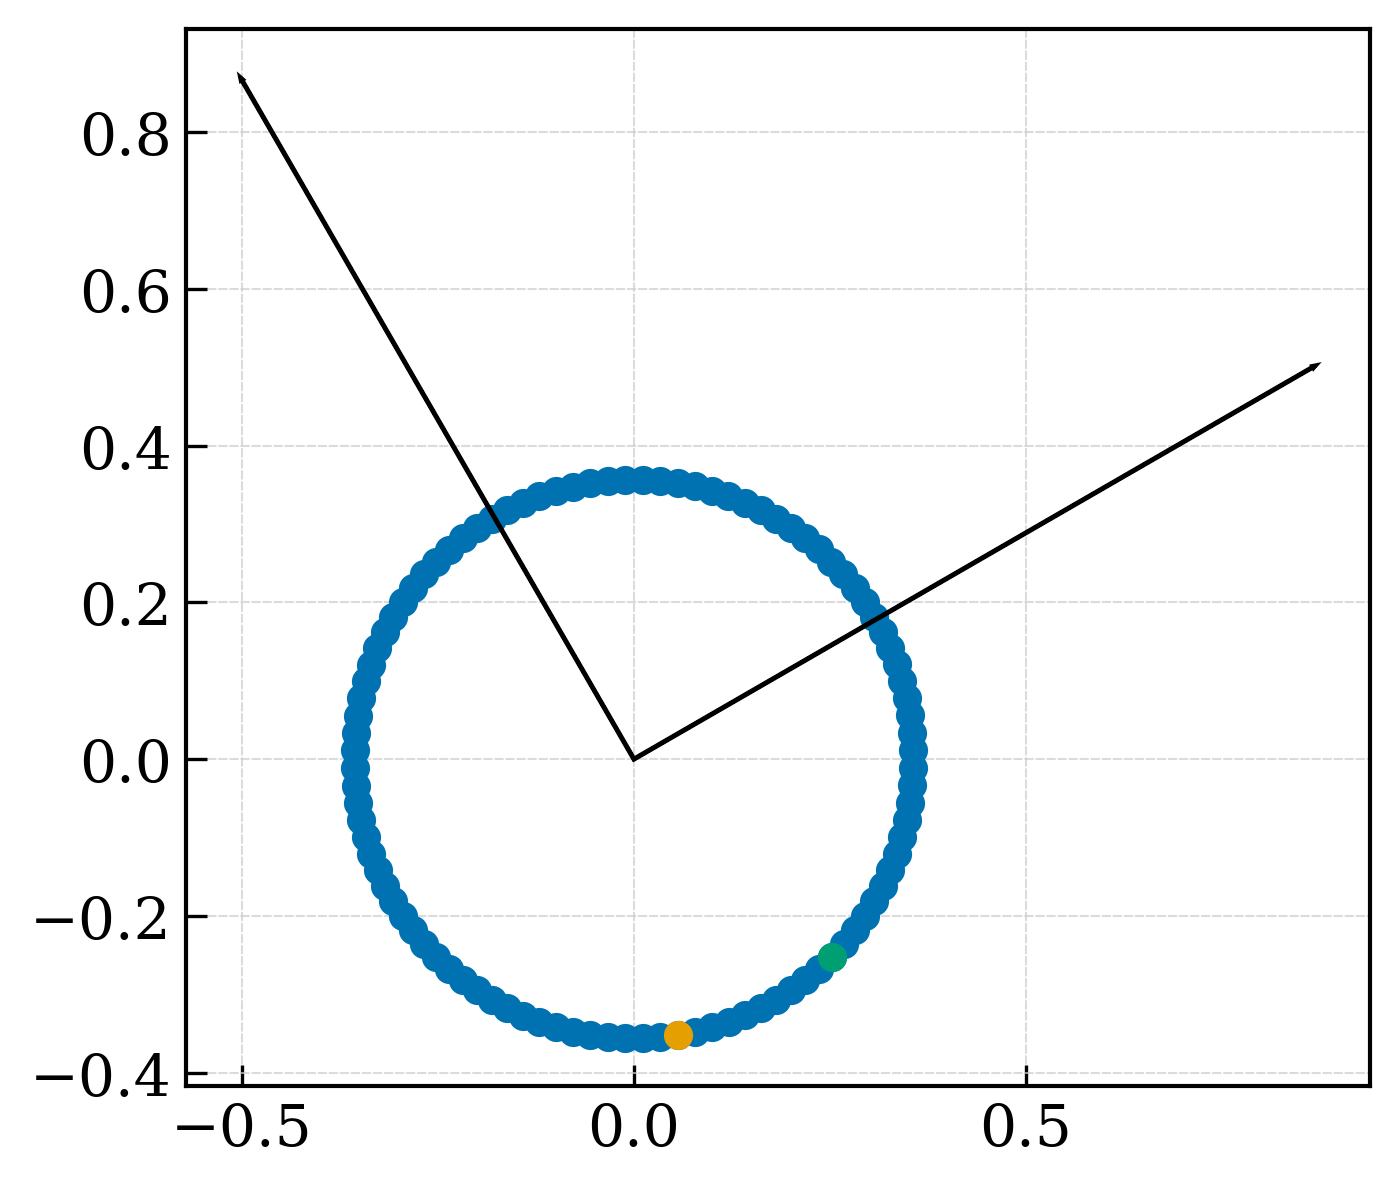

In [218]:
# directions of A, B oscillations for atomsat index 0
a = np.array([np.sqrt(3)/2, 0.5, 0])
b = np.array([-0.5, np.sqrt(3)/2, 0])

fig, ax = plt.subplots()
ax.scatter(positions[:,0] - np.mean(positions[:,0]), positions[:,1]- np.mean(positions[:,1]))
ax.scatter(positions[0,0] - np.mean(positions[:,0]), positions[0,1]- np.mean(positions[:,1]))
ax.scatter(positions[10,0]- np.mean(positions[:,0]), positions[10,1]- np.mean(positions[:,1]))

ax.arrow(0, 0, a[0], a[1])
ax.arrow(0, 0, b[0], b[1])
ax.set_aspect("equal")


In [219]:
# Center the data
xy_centered = positions[:, :2] - np.mean(positions[:, :2], axis=0)

# Calculate the covariance matrix
cov = np.cov(xy_centered.T)

# Get eigenvalues and eigenvectors
eigenvalues, eigenvectors = np.linalg.eig(cov)

# Sort them so the largest eigenvalue comes first
idx = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[idx]
eigenvectors = eigenvectors[:, idx]

# For a uniformly or sinusoidally traced ellipse, the actual physical amplitudes
# can be found by projecting the data onto the eigenvectors
projected = xy_centered @ eigenvectors
semi_major_length = np.max(np.abs(projected[:, 0]))
semi_minor_length = np.max(np.abs(projected[:, 1]))

# Angle of the major axis
tilt_angle_deg = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))

print(f"Semi-major axis length: {semi_major_length:.6f}")
print(f"Semi-minor axis length: {semi_minor_length:.6f}")
print(f"Ellipse tilt angle: {tilt_angle_deg:.2f} degrees")

Semi-major axis length: 0.356265
Semi-minor axis length: 0.356224
Ellipse tilt angle: 17.42 degrees


In [220]:
displacements = np.array([a.positions for a in phonon_mode]) - (deformed_primitive * (9,9,1)).positions

In [221]:
adot = np.dot(positions, a)
bdot = np.dot(positions, b)

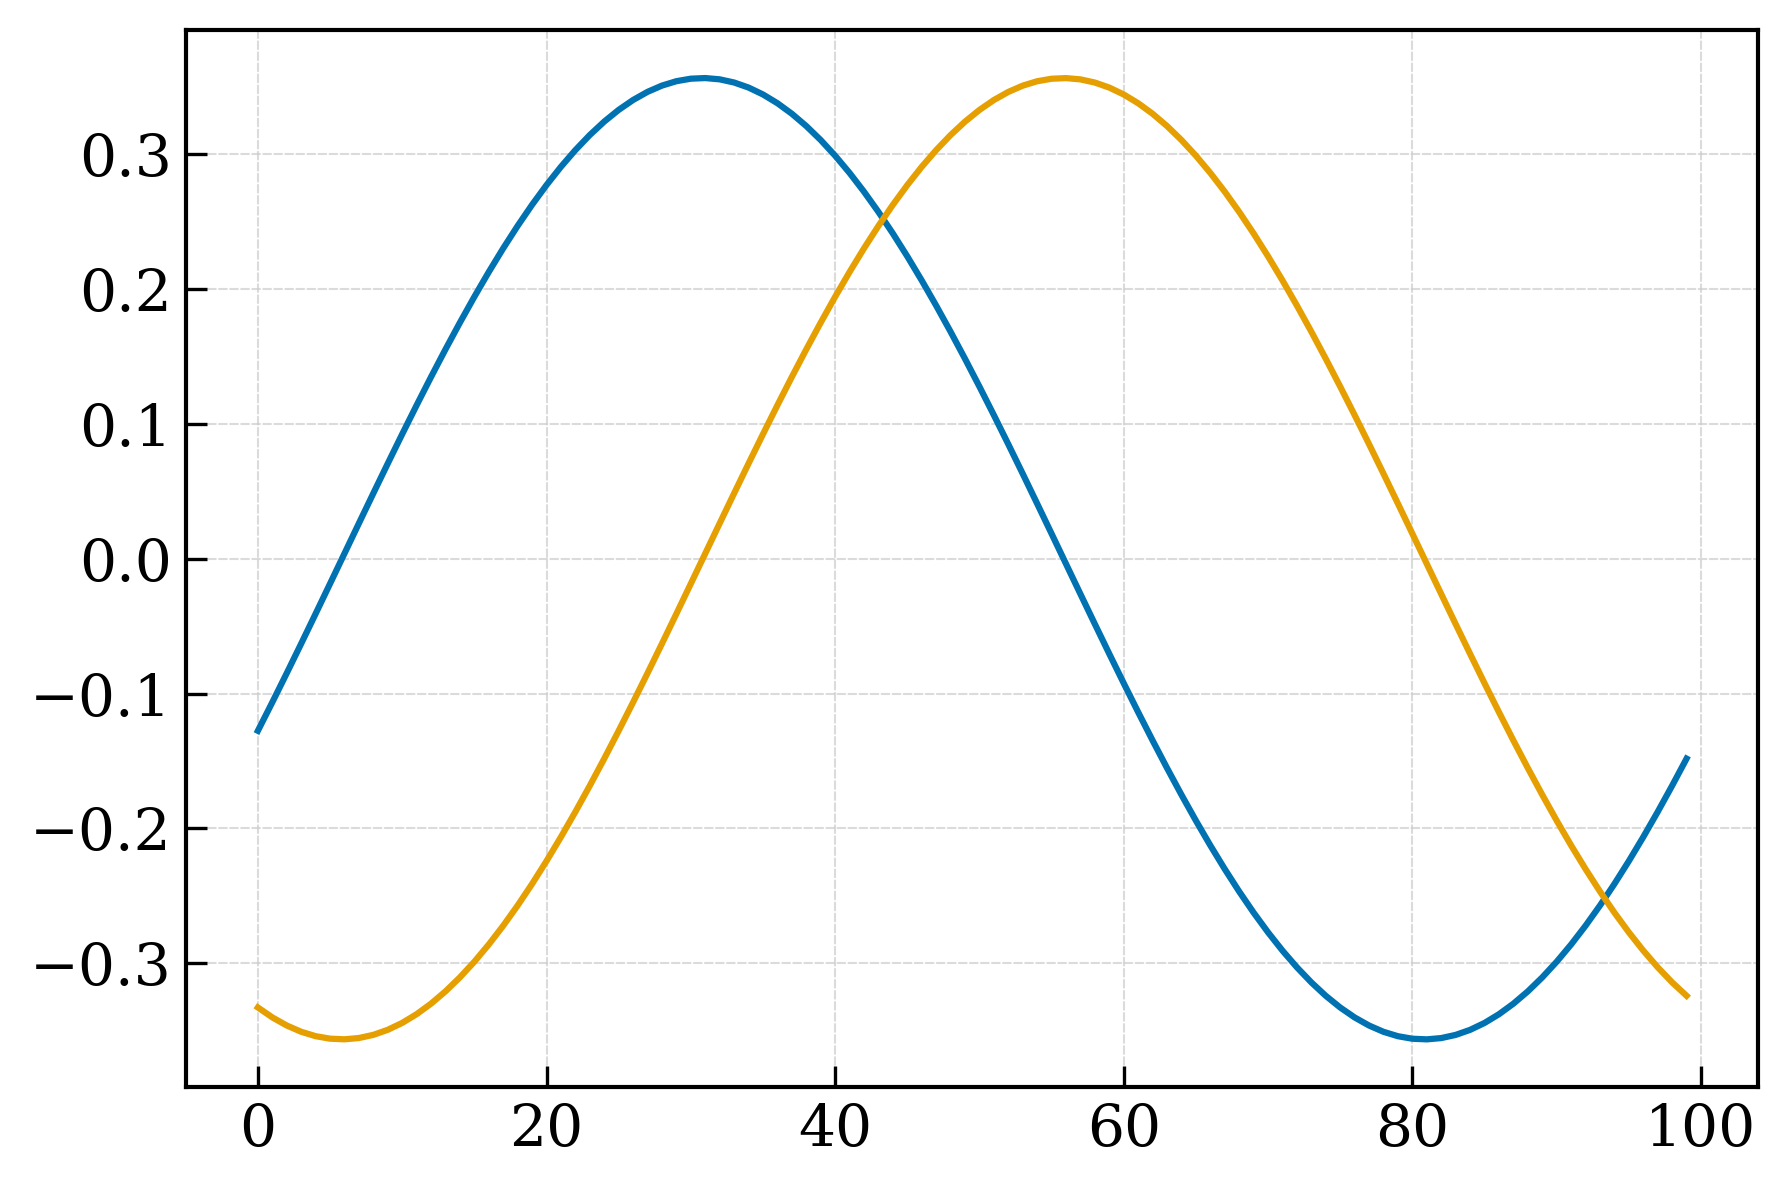

In [222]:
plt.plot(adot)
plt.plot(bdot)

In [223]:
lam = np.sqrt(adot[0]**2 + bdot[0]**2)
phi0a = np.acos(adot[0] / lam)
phi0b = np.asin(bdot[0]/lam)

In [224]:
print(lam, phi0a, phi0b, phi0a - phi0b)

0.3563022882401191 1.936950533656902 -1.2046421199328914 3.141592653589793


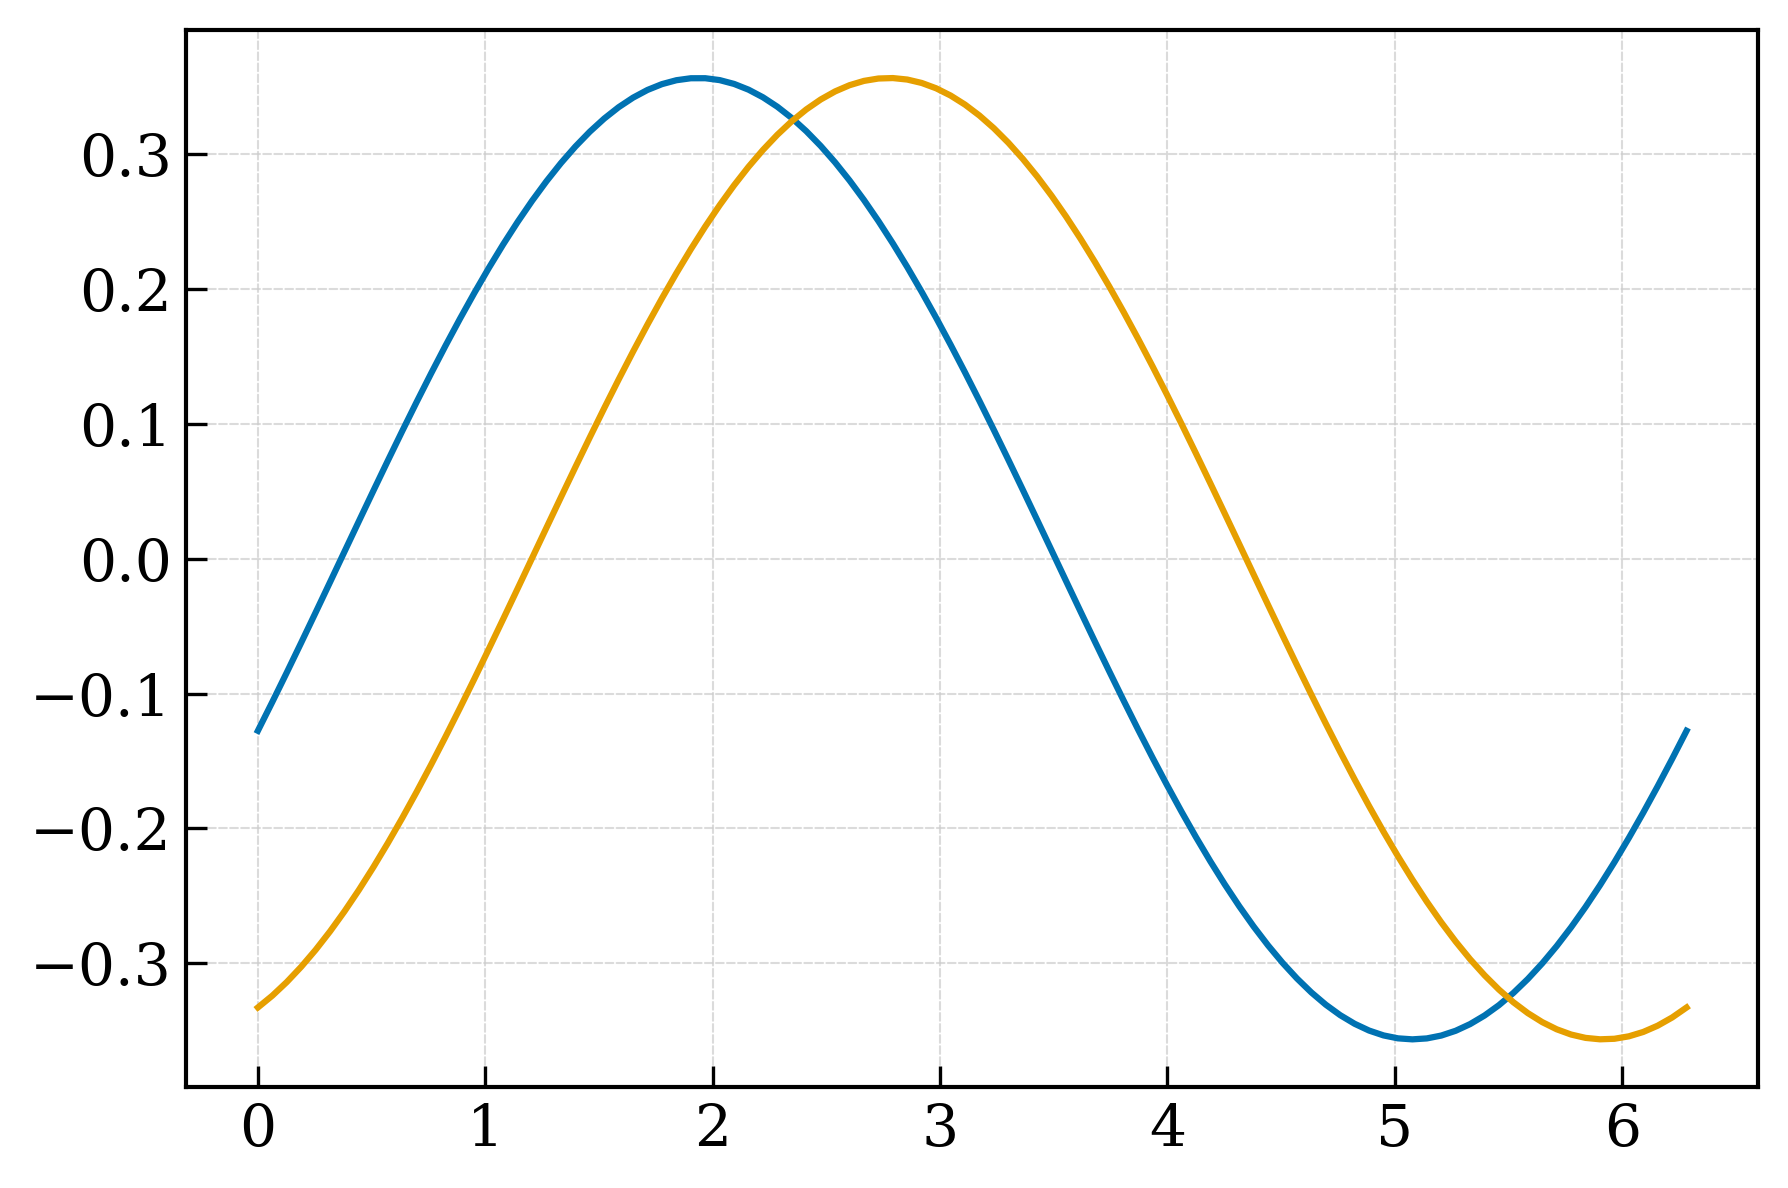

In [225]:
ts = np.linspace(0, 2*np.pi, 100)
plt.plot(ts, lam * np.cos(-ts + phi0a))
plt.plot(ts, lam * np.sin(ts + phi0b))

In [226]:
import numpy as np

A = lam
phi0 = phi0a
phis = np.linspace(0, 2 * np.pi, 100)

# Generate the 100 u vectors (with a bit of added noise)
X_coef = A * np.cos(phis - phi0)
Y_coef = A * np.sin(phis - phi0)

# --- 2. The Solution ---
# Construct the design matrix M (100 x 2)
# M shape: (100, 2)
M = np.column_stack((X_coef, Y_coef))

# Compute the Moore-Penrose pseudo-inverse of M. Shape: (2, 100)
M_pinv = np.linalg.pinv(M)

# Use np.einsum or np.tensordot to multiply: (2, 100) x (100, 162, 3)
# This perfectly maps the 100 phis away, leaving you with (2, 162, 3)
modes = np.einsum('ij,jkl->ikl', M_pinv, displacements)

a_est = modes[0, :, :]  # Shape: (162, 3)
b_est = modes[1, :, :]  # Shape: (162, 3)

In [227]:
# a_est = a_est / np.linalg.norm(a_est)
# b_est = b_est / np.linalg.norm(b_est)

In [228]:
amodes = []
bmodes = []

start = deformed_primitive * (9,9,1)
pos0 = start.positions

amplitudes = np.linspace(-0.5, 0.5, 50)


amodes, bmodes, aenergies, benergies = [], [], [], []

for a in amplitudes:
    amode = start.copy()
    amode.set_positions(pos0 + a_est * a)
    amode.calc = model
    amodes.append(amode)
    aenergies.append(amode.get_potential_energy())

    bmode = start.copy()
    bmode.set_positions(pos0 + b_est * a)
    bmode.calc = model
    bmodes.append(bmode)
    benergies.append(bmode.get_potential_energy())

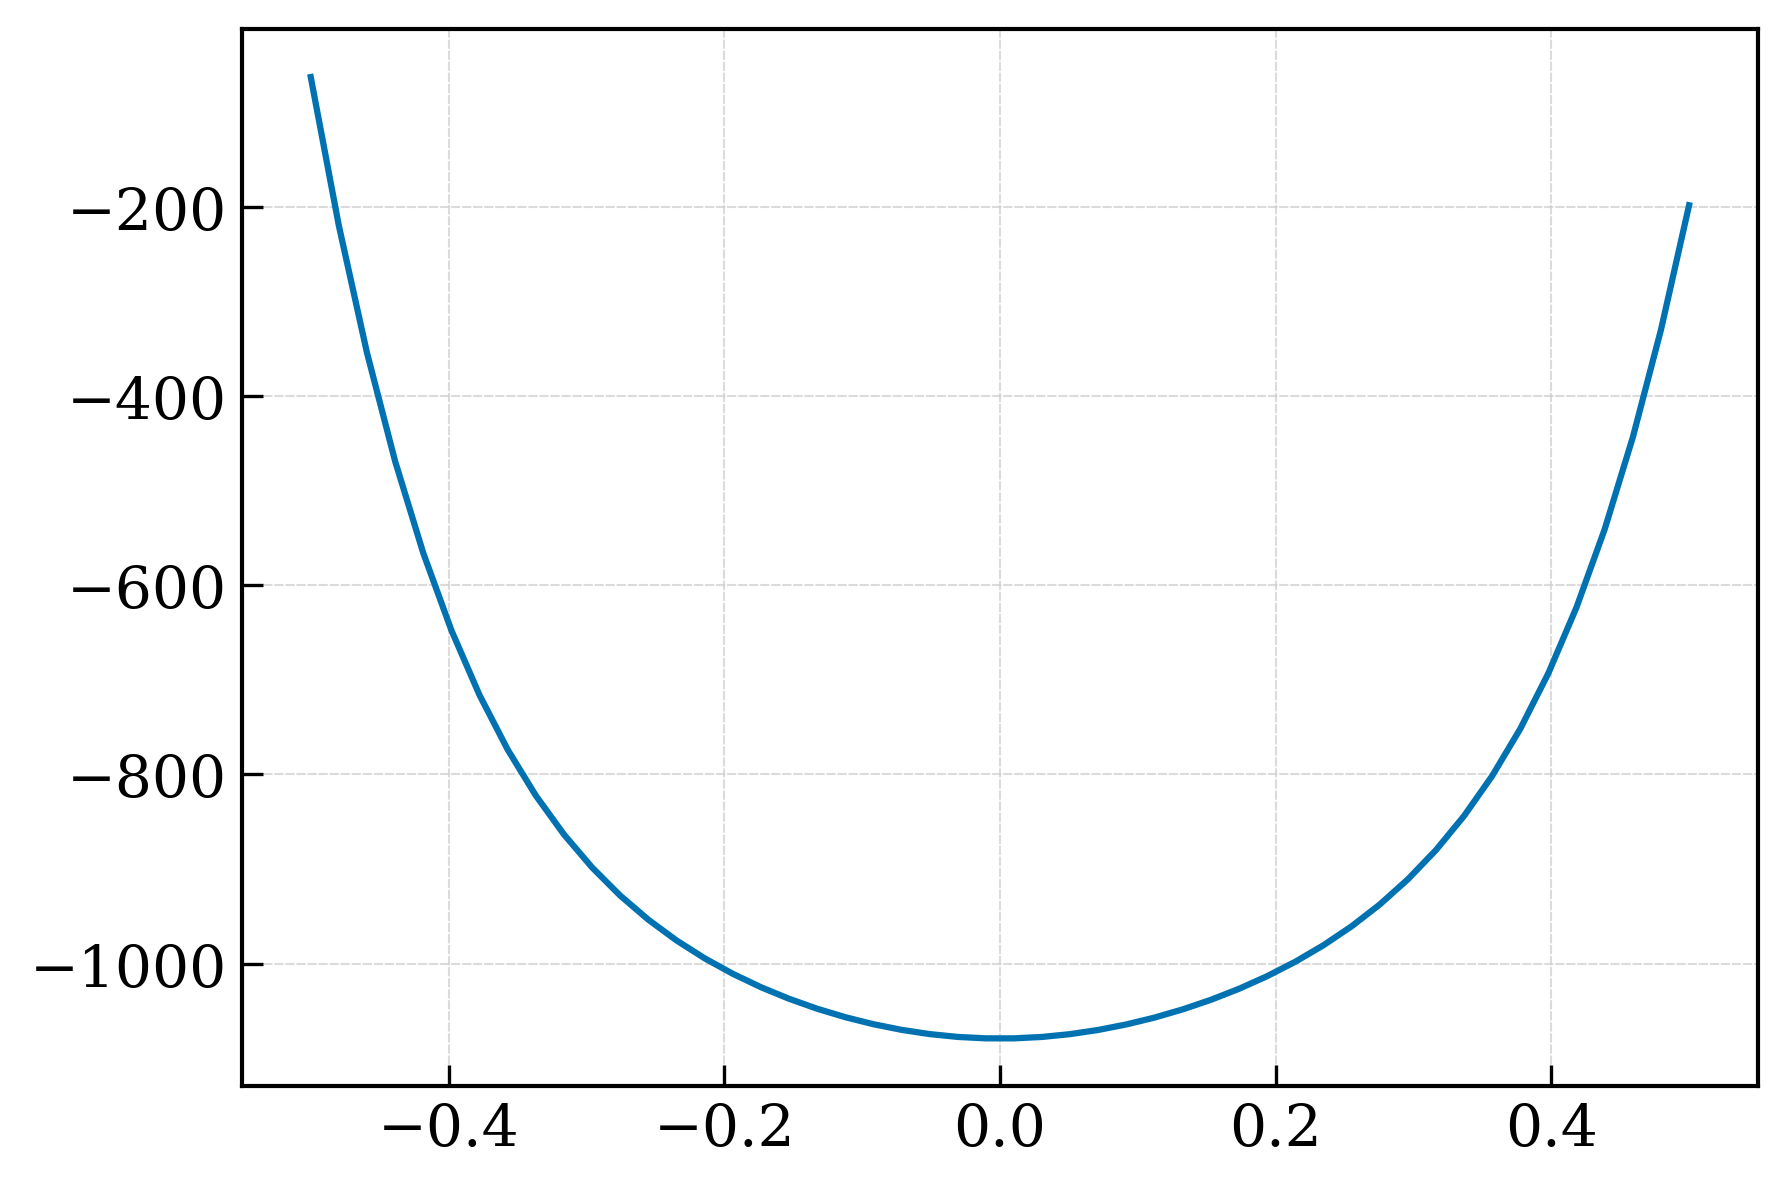

In [229]:
plt.plot(amplitudes, benergies)

In [230]:
view(amodes, viewer="ngl")